# OR–odorant functional landscape

Four activation matrices, each clustered (Jaccard + PAM, k=6) with hypergeometric + BH enrichment:

- **baseline** — predictions at the model default, p ≥ 0.50
- **calibrated** — predictions at the calibrated threshold derived below
- **hybrid_baseline** — M2OR ground truth over the baseline fill
- **hybrid_calibrated** — M2OR ground truth over the calibrated fill

`hybrid_calibrated` is the main matrix and its figures render inline. The other three
are written to `Figures/` as supplementary.

In [1]:
import numpy as np, pandas as pd, matplotlib, re
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch
from scipy.spatial.distance import pdist, squareform
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.stats import hypergeom, mannwhitneyu
from collections import Counter
from rdkit import Chem
from rdkit.Chem import Descriptors, Crippen, rdMolDescriptors, Lipinski
np.random.seed(0)

import sys
sys.path.append("../../scripts")
from plotting_functions import custom_plots, FIGSIZE
plt.rcParams.update(custom_plots())

PROB   = "../../predictions/aggregated/Reference_Tree_Predictions/reference_median_probability_wide.csv"
PAIRS  = "../../../Model/Data_Preparation/processed/m2or_pairs_model.csv"   # smiles_id <-> SMILES, experimental Responsive, Sequence
ODORS  = "../../predictions/aggregated/ASR_Predictions_RefTree/inchi_smiles_odors.csv"   # SMILES -> Odors
FASTA  = "../../../Phylogenetic_Analysis/data/ReferenceTree/PF13853.9606_7955_7740_7764_75743_137246.fa"
CLASSES= "../../../Phylogenetic_Analysis/data/HumanTree/human433_OR_classes.csv"
TREE   = "../../../Phylogenetic_Analysis/data/HumanTree/human433_MFP_reorder.tree"
CLASS_I_COL='#7f1734'; CLASS_II_COL='#557c99'
OUTDIR = 'Figures'
K = 6

## 1 · Data: probability matrix, human ORs

In [2]:
import os; os.makedirs(OUTDIR, exist_ok=True)
prob=pd.read_csv(PROB,index_col=0)
hum_pids=[i for i in prob.index if str(i).startswith('9606')]
P=prob.loc[hum_pids]; lig_cols=list(P.columns); Pv=P.values
print('human probability matrix:',Pv.shape)

human probability matrix: (433, 754)


## 2 · Experimental layer — exact amino-acid sequence match (23,782 pairs)

In [3]:
pid2seq={}; pid=None; buf=[]
for line in open(FASTA):
    line=line.rstrip()
    if line.startswith('>'):
        if pid: pid2seq[pid]=''.join(buf).upper()
        pid=line[1:].split()[0]; buf=[]
    else: buf.append(line)
if pid: pid2seq[pid]=''.join(buf).upper()
seq2pid={}
for p in hum_pids: seq2pid.setdefault(pid2seq[p],[]).append(p)
m=pd.read_csv(PAIRS,usecols=['Species','UniProt ID','Sequence','Responsive','smiles_id','mutation'])
hs=m[m['Species'].str.lower().str.contains('homo')].copy()
hs['Sequence']=hs['Sequence'].str.upper().str.strip()
hs['pid']=hs['Sequence'].map(lambda s: seq2pid.get(s,[None])[0])
matched=hs[hs['pid'].notna() & hs['smiles_id'].isin(set(lig_cols))]
exp=matched.groupby(['pid','smiles_id'])['Responsive'].max().reset_index()
print('overlapping human pairs:',len(exp),'(ground truth 23,782)')

overlapping human pairs: 23782 (ground truth 23,782)


## 3 · Calibrated threshold

Same derivation as `01.model_behaviour`: the cut where the predicted binding proportion
matches the measured one, on these 23,782 cells.

In [4]:
ridx={p:i for i,p in enumerate(hum_pids)}; cidx={c:j for j,c in enumerate(lig_cols)}
y_true=exp['Responsive'].values.astype(int)
y_prob=np.array([Pv[ridx[r.pid],cidx[r.smiles_id]] for r in exp.itertuples()])

grid=np.arange(0.50,0.9990,0.0001)
CALIB_THR=float(grid[np.abs(np.array([(y_prob>t).mean() for t in grid])-y_true.mean()).argmin()])
print('measured binding proportion: %.4f%%'%(100*y_true.mean()))
print('calibrated threshold       : %.4f'%CALIB_THR)

measured binding proportion: 4.7431%
calibrated threshold       : 0.9150


## 4 · Odor-tag map

In [5]:
pairs=pd.read_csv(PAIRS,usecols=['SMILES','smiles_id'])
sml2smiles=pairs.drop_duplicates('smiles_id').set_index('smiles_id')['SMILES'].to_dict()
odo=pd.read_csv(ODORS)
smiles2tags={s:[t.strip().lower() for t in o.split(',') if t.strip()]
             for s,o in zip(odo['SMILES'],odo['Odors']) if isinstance(o,str) and o.strip()}
sml2tags_all={sid:smiles2tags[sml2smiles[sid]] for sid in lig_cols if sml2smiles.get(sid) in smiles2tags}
print('tagged odorants:',len(sml2tags_all),'/',len(lig_cols))

tagged odorants: 575 / 754


In [6]:
sml2tags_all

{'SML0000': ['terpenic', 'peppery', 'herbal', 'pine', 'orange'],
 'SML0001': ['minty', 'bready', 'spicy'],
 'SML0002': ['mentholic'],
 'SML0003': ['balsamic',
  'winey',
  'oily',
  'solvent',
  'fermented',
  'sweet',
  'alcoholic'],
 'SML0005': ['soapy',
  'honey',
  'fatty',
  'oily',
  'citrus',
  'floral',
  'coconut',
  'earthy',
  'waxy'],
 'SML0006': ['musty',
  'fermented',
  'pear',
  'sweet',
  'fruity',
  'alcoholic',
  'apple'],
 'SML0007': ['cheesy', 'fatty', 'buttery', 'oily', 'sweet'],
 'SML0008': ['powdery',
  'musty',
  'chocolate',
  'nutty',
  'earthy',
  'roasted',
  'woody',
  'cocoa',
  'medicinal',
  'grassy'],
 'SML0009': ['leathery',
  'fatty',
  'winey',
  'solvent',
  'fermented',
  'ethereal',
  'cocoa',
  'alcoholic'],
 'SML0010': ['rummy', 'winey', 'grape', 'sweet', 'waxy', 'fruity', 'ethereal'],
 'SML0011': ['herbal',
  'oily',
  'fermented',
  'nutty',
  'sweet',
  'fruity',
  'ethereal'],
 'SML0012': ['terpenic',
  'cooling',
  'herbal',
  'sweet',
  '

## 5 · Receptor classes and phylogenetic row order

In [7]:
cls=pd.read_csv(CLASSES)
pid2class={r.leaf_id:('I' if r.OR_class.split('_')[1]=='I' else 'II') for r in cls.itertuples()}
n_I=sum(v=='I' for v in pid2class.values()); n_II=sum(v=='II' for v in pid2class.values())
tree_order=re.findall(r'[\(,]([^(),:;]+):', open(TREE).read())   # ladderized tip order
assert set(tree_order)==set(hum_pids)
print('Class I:',n_I,'Class II:',n_II,'| tree tips:',len(tree_order))

Class I: 62 Class II: 371 | tree tips: 433


## 6 · Palette and helpers

In [8]:
theme_rules = [
    (('acidic','sour','cheesy','dairy'),                       'Acid / Dairy / Cheese',       '#543005'),
    (('chemical','potato','vanilla','roasted','phenolic','popcorn','spicy'),'Roasted / Phenolic / Spice','#ae7121'),
    (('plum','jasmine','floral','balsamic'),                   'Floral / Balsamic',           '#e7cf94'),
    (('lavender','violet','green','fresh','herbal','citrus'),  'Fresh / Green / Herbal',      '#98d7cd'),
    (('cognac','coconut','pineapple','aldehydic','fruity','waxy','buttery'),'Fruity / Fatty / Aldehydic','#98d7cd'),
    (('alcoholic','ethereal','medicinal','fermented','smoky','rum','solvent'),'Fermented / Solvent','#24877f'),
    (('musk','animal','grapefruit'),                           'Musk / Animal',               '#003c30')]
SHORT={'Acid / Dairy / Cheese':'Acid·Dairy','Roasted / Phenolic / Spice':'Roasted·Spice','Floral / Balsamic':'Floral',
       'Fresh / Green / Herbal':'Fresh·Green','Fruity / Fatty / Aldehydic':'Fruity·Fatty','Fermented / Solvent':'Fermented','Musk / Animal':'Musk·Animal'}

SHOW=False          # run_matrix flips this for the matrix shown inline

def save(fig,name):
    fig.savefig(f'{OUTDIR}/{name}.svg', bbox_inches='tight')
    if SHOW: plt.show()
    else: plt.close(fig)

def _cliffs(a,b):
    a=np.asarray(a,float); b=np.asarray(b,float)
    return float(np.sign(a[:,None]-b[None,:]).mean())   # >0 => first group larger

def kmedoids(D,k,n_init=15,seed=0):
    rng=np.random.default_rng(seed); n=len(D); best=None
    for _ in range(n_init):
        med=rng.choice(n,k,replace=False)
        for _ in range(300):
            lab=D[:,med].argmin(1); nm=med.copy()
            for c in range(k):
                idx=np.where(lab==c)[0]
                if len(idx): nm[c]=idx[D[np.ix_(idx,idx)].sum(1).argmin()]
            if set(nm)==set(med): med=nm; break
            med=nm
        lab=D[:,med].argmin(1); cost=D[np.arange(n),med[lab]].sum()
        if best is None or cost<best[0]: best=(cost,lab.copy())
    return best[1]

def bh(p):
    p=np.asarray(p); m=len(p); o=np.argsort(p); r=p[o]
    q=np.minimum.accumulate((r*m/(np.arange(m)+1))[::-1])[::-1]; out=np.empty(m); out[o]=np.clip(q,0,1); return out

def cluster_and_enrich(X,K=6):
    cols=np.array(lig_cols); keep=X.sum(0)>0; lig,Xn=cols[keep],X[:,keep]
    Dj=np.nan_to_num(squareform(pdist(Xn.T,'jaccard'))); lab=kmedoids(Dj,K)
    s2t={s:sml2tags_all[s] for s in lig if s in sml2tags_all}
    tagged=np.array([s in s2t for s in lig]); tagN=Counter([t for s in lig[tagged] for t in s2t[s]]); N=int(tagged.sum())
    tags=[t for t,c in tagN.items() if c>=5]; rows=[]
    for c in range(K):
        mem=[s for s in lig[lab==c] if s in s2t]; n=len(mem); ct=Counter([t for s in mem for t in s2t[s]])
        for t in tags:
            kk=ct.get(t,0); Kt=tagN[t]; e=n*Kt/N; oe=kk/e if e>0 else 0
            p=hypergeom.sf(kk-1,N,Kt,n) if kk>0 else 1.0
            rows.append([c,n,t,kk,Kt,round(e,3),round(oe,3),p])
    enr=pd.DataFrame(rows,columns=['cluster','n','tag','obs','tag_total','exp','obs_exp','p'])
    enr['fdr']=bh(enr['p'].values); sig=enr[(enr.fdr<0.05)&(enr.obs_exp>1)]
    # bijective theme assignment: every cluster gets a DISTINCT colour
    score={}
    for c in range(K):
        s=sig[sig.cluster==c]
        for ti,(keys,nm,col) in enumerate(theme_rules):
            hit=s[s.tag.isin(keys)]
            if len(hit): score[(c,ti)]=float(hit.obs_exp.max())
    meta={c:None for c in range(K)}; used=set()
    for (c,ti),sc in sorted(score.items(),key=lambda x:-x[1]):
        keys,nm,col=theme_rules[ti]
        if meta[c] is None and col not in used:
            meta[c]=dict(name=nm,color=col,size=int((lab==c).sum())); used.add(col)
    palette=list(dict.fromkeys(col for _,_,col in theme_rules))
    for c in range(K):
        if meta[c] is None:
            col=next((x for x in palette if x not in used),'#8a8a8a')
            top=sig[sig.cluster==c].sort_values('obs_exp',ascending=False).tag.tolist()
            meta[c]=dict(name=top[0].capitalize() if top else f'cluster{c}',color=col,size=int((lab==c).sum())); used.add(col)
    order={col:i for i,col in enumerate(palette)}
    cl_order=sorted(range(K),key=lambda c: order.get(meta[c]['color'],99))
    return lig,Xn,lab,enr,sig,meta,cl_order

### Activation heatmap — class stripe (left), breadth (right); rows in co-tuning **or** phylogenetic order

In [9]:
def activation_heatmap(lig,Xn,lab,meta,cl_order,name,title,subtitle,roworder='cotuning',K=6):
    if roworder=='tree':
        ridx={p:i for i,p in enumerate(hum_pids)}; row_pos=np.array([ridx[p] for p in tree_order])
        ylab='433 human ORs (phylogenetic order)'; fname=f'heatmap_{name}_tree_order'
    else:
        row_pos=leaves_list(linkage(squareform(np.nan_to_num(squareform(pdist(Xn,'jaccard')))),'average'))
        ylab='433 human ORs (co-tuning order)'; fname=f'heatmap_{name}'
    col_index=[]; bounds=[]; pos=0
    for c in cl_order:
        idx=np.where(lab==c)[0]
        if len(idx)>2: idx=idx[leaves_list(linkage(np.nan_to_num(pdist(Xn[:,idx].T,'jaccard')),'average'))]
        col_index+=idx.tolist(); pos+=len(idx); bounds.append(pos)
    col_index=np.array(col_index); M=Xn[np.ix_(row_pos,col_index)]; starts=[0]+bounds[:-1]
    fig=plt.figure(figsize=(12.4,7.6))
    gs=fig.add_gridspec(2,3,width_ratios=[0.11,4,0.11],height_ratios=[0.14,4],hspace=0.028,wspace=0.02,left=0.055,right=0.94,top=0.83,bottom=0.135)
    ax=fig.add_subplot(gs[1,1])
    ax.imshow(M,aspect='auto',cmap=ListedColormap(['#F4F1EA','#2E4057']),interpolation='nearest',rasterized=True)
    ax.set_xticks([]); ax.set_yticks([])
    for sp in ax.spines.values(): sp.set_edgecolor('#bbb'); sp.set_linewidth(0.6)
    for i in range(1,len(bounds)): ax.axvline(starts[i]-0.5,color='white',lw=1.8)
    ax.set_xlabel(f'{len(lig)} odorants — co-tuning cluster (Jaccard, PAM, k={K})',fontsize=10.5,labelpad=8,color='#8a8a86')
    ax.set_ylabel(ylab,fontsize=10.5,color='#8a8a86')
    axtop=fig.add_subplot(gs[0,1],sharex=ax)
    axtop.imshow(np.array([[matplotlib.colors.to_rgb(meta[lab[j]]['color']) for j in col_index]]),aspect='auto',interpolation='nearest',extent=[0,len(col_index),0,1])
    axtop.set_xlim(0,len(col_index)); axtop.set_ylim(0,1); axtop.set_xticks([]); axtop.set_yticks([])
    for sp in axtop.spines.values(): sp.set_visible(False)
    for i,c in enumerate(cl_order):
        axtop.text((starts[i]+bounds[i])/2,1.55,SHORT.get(meta[c]['name'],meta[c]['name'][:10]),ha='center',va='bottom',fontsize=9,color=meta[c]['color'],fontweight='bold',clip_on=False)
    axcls=fig.add_subplot(gs[1,0],sharey=ax)
    axcls.imshow(np.array([[matplotlib.colors.to_rgb(CLASS_I_COL if pid2class[hum_pids[j]]=='I' else CLASS_II_COL)] for j in row_pos]),aspect='auto',interpolation='nearest')
    axcls.set_xticks([]); axcls.set_yticks([])
    for sp in axcls.spines.values(): sp.set_visible(False)
    axcls.set_xlabel('class',fontsize=7.5,color='#8a8a86',labelpad=4)
    axbr=fig.add_subplot(gs[1,2],sharey=ax)
    axbr.imshow(Xn.sum(1)[row_pos].reshape(-1,1),aspect='auto',cmap='Greys',interpolation='nearest',rasterized=True)
    axbr.set_xticks([]); axbr.set_yticks([])
    for sp in axbr.spines.values(): sp.set_visible(False)
    axbr.set_xlabel('breadth',fontsize=7.5,color='#8a8a86',labelpad=4)
    ax.legend(handles=[Patch(fc=CLASS_I_COL,label='Class I'),Patch(fc=CLASS_II_COL,label='Class II'),Patch(fc='#2E4057',label='binding'),Patch(fc='#F4F1EA',ec='#bbb',label='no binding')],
              loc='upper left',bbox_to_anchor=(0,-0.05),ncol=4,frameon=False,fontsize=9,handlelength=1.1,columnspacing=1.4,labelcolor='#8a8a86')
    fig.suptitle(title,fontsize=12.5,y=0.965,x=0.5,fontweight='bold',color='#6b6b67')
    fig.text(0.5,0.905,subtitle,ha='center',fontsize=9.5,color='#a5a5a0')
    save(fig,fname)

### PCoA — principal coordinate analysis of the co-tuning space
Classical (metric) MDS: embeds the molecules from their pairwise **Jaccard** dissimilarity (shared receptor activation — the same distance used for clustering) into Euclidean axes that best preserve those distances. PCoA rather than PCA because Jaccard is non-Euclidean. Axes are ordered by variance explained (eigenvalue share); points close together activate similar receptor sets; colour = PAM cluster.

In [10]:
def pcoa(D):
    D=np.asarray(D,float); n=len(D); D2=D**2
    J=np.eye(n)-np.ones((n,n))/n; B=-0.5*J.dot(D2).dot(J)
    ev,evec=np.linalg.eigh((B+B.T)/2); idx=np.argsort(ev)[::-1]; ev=ev[idx]; evec=evec[:,idx]
    pos=ev>1e-9; return evec[:,pos]*np.sqrt(ev[pos]), ev
def pcoa_plot(Xn,lab,meta,cl_order,name,title):
    Dj=np.nan_to_num(squareform(pdist(Xn.T,"jaccard"))); coords,ev=pcoa(Dj)
    tot=ev[ev>0].sum(); v1,v2=100*ev[0]/tot,100*ev[1]/tot
    neg=100*(-ev[ev<0].sum())/(np.abs(ev).sum())
    fig,ax=plt.subplots(figsize=(7.6,6.8))
    for c in cl_order:
        m=lab==c; P=coords[m,:2]
        ax.scatter(P[:,0],P[:,1],s=15,color=meta[c]["color"],alpha=0.75,edgecolor="none",label=f'{meta[c]["name"]} (n={meta[c]["size"]})',zorder=3)
    ax.axhline(0,color="#e5e5e2",lw=0.6,zorder=0); ax.axvline(0,color="#e5e5e2",lw=0.6,zorder=0)
    ax.set_xlabel(f"PCo1 ({v1:.1f}%)",fontsize=10.5,color="#8a8a86"); ax.set_ylabel(f"PCo2 ({v2:.1f}%)",fontsize=10.5,color="#8a8a86")
    for sp in ["top","right"]: ax.spines[sp].set_visible(False)
    ax.tick_params(labelsize=8); ax.legend(frameon=False,fontsize=8.3,loc="best",labelcolor="#6b6b67")
    ax.set_title(title,fontsize=12.5,fontweight="bold",color="#6b6b67")
    ax.text(0.99,0.01,f"non-Euclidean (neg. eigenvalue mass {neg:.0f}%)",transform=ax.transAxes,ha="right",va="bottom",fontsize=7,color="#b5b5b0")
    save(fig,f"pcoa_{name}")

### Enrichment bar plot — fold enrichment, q-value labels (screenshot style)

In [11]:
def _fmtq(q):
    if q<1e-5: return 'q<1e-5'
    if q<1e-3: return 'q=%.0e'%q
    return 'q=%.3f'%q

def enrichment_bars(enr,sig,meta,cl_order,name,title):
    rows=[]
    for c in cl_order:
        for r in sig[sig.cluster==c].sort_values('obs_exp',ascending=False).itertuples():
            rows.append((c,r.tag,r.obs_exp,r.fdr))
    if not rows: return
    ys=[]; labels=[]; colors=[]; folds=[]; qs=[]; y=0; last=None
    for c,tag,fold,q in rows:
        if last is not None and c!=last: y-=1
        ys.append(y); labels.append(tag); colors.append(meta[c]['color']); folds.append(fold); qs.append(q); y-=1; last=c
    ys=np.array(ys); folds=np.array(folds)
    fig,ax=plt.subplots(figsize=(8.6,0.3*(len(labels)+len(cl_order))+1))
    ax.barh(ys,folds,color=colors,alpha=0.92,height=0.74)
    ax.axvline(1,color='#8a8a86',ls='--',lw=1.0)
    xm=folds.max()
    for yi,f,q in zip(ys,folds,qs): ax.text(f+xm*0.015,yi,_fmtq(q),va='center',ha='left',fontsize=7.6,color='#8a8a86')
    ax.set_yticks(ys); ax.set_yticklabels(labels,fontsize=8.5)
    for tl,c in zip(ax.get_yticklabels(),colors): tl.set_color(c)
    ax.set_xlim(0,xm*1.30); ax.set_ylim(ys.min()-1,ys.max()+1)
    ax.set_xlabel('fold enrichment of odour descriptor  (observed / expected)',fontsize=10)
    ax.set_title(title,fontsize=12,fontweight='bold',color='#6b6b67')
    for sp in ['top','right','left']: ax.spines[sp].set_visible(False)
    ax.tick_params(left=False)
    save(fig,f'enrichbar_{name}')

### Chemistry figures — Class I vs II (receptor-level) and clusters (Kruskal-Wallis), as two separate figures

In [12]:
from scipy.stats import kruskal

def ligand_descriptors(lig, keys):
    """RDKit descriptors for a ligand set; shared by the cluster and class panels."""
    fns={'OxygenAtoms':lambda m: sum(a.GetAtomicNum()==8 for a in m.GetAtoms()),
         'HBD':Lipinski.NumHDonors,'TPSA':rdMolDescriptors.CalcTPSA,
         'RotBonds':Descriptors.NumRotatableBonds,'AromaticRings':rdMolDescriptors.CalcNumAromaticRings,
         'LogP':Crippen.MolLogP,'RingCount':rdMolDescriptors.CalcNumRings,
         'FracCSP3':rdMolDescriptors.CalcFractionCSP3}
    vals={k:np.full(len(lig),np.nan) for k in keys}
    for i,sid in enumerate(lig):
        sm=sml2smiles.get(sid); mol=Chem.MolFromSmiles(sm) if isinstance(sm,str) else None
        if mol is None: continue
        for k in keys: vals[k][i]=fns[k](mol)
    return vals

def chem_clusters(lig, Xn, lab, meta, cl_order, name):
    keys=['RingCount','FracCSP3','LogP','TPSA','AromaticRings','OxygenAtoms','RotBonds','HBD']
    vals=ligand_descriptors(lig,keys); valid=~np.isnan(vals['LogP'])

    # ---------- Figure 2 : clusters (odorant-level, Kruskal-Wallis) ----------
    descB=[('RingCount','rings'),('FracCSP3','sp\u00b3 fraction'),('LogP','lipophilicity (LogP)')]
    kwset=['RingCount','FracCSP3','LogP','TPSA','AromaticRings','OxygenAtoms','RotBonds','HBD']
    kwp={}
    for k in kwset:
        try: kwp[k]=kruskal(*[vals[k][(lab==c)&valid] for c in cl_order])[1]
        except Exception: kwp[k]=np.nan
    ks=list(kwp); pp=np.array([kwp[k] for k in ks]); mm=len(pp); oo=np.argsort(pp); q=np.empty(mm); rk=pp[oo]
    q[oo]=np.clip(np.minimum.accumulate((rk*mm/(np.arange(mm)+1))[::-1])[::-1],0,1); qmap=dict(zip(ks,q))
    fq=lambda x: ('q=%.0e'%x if x<1e-3 else 'q=%.2f'%x)
    fig,axB=plt.subplots(1,3,figsize=(8.4,4.3))
    for ax,(k,lb) in zip(axB,descB):
        data=[vals[k][(lab==c)&valid] for c in cl_order]
        vp=ax.violinplot(data,positions=range(len(cl_order)),widths=0.85,showmedians=False,showextrema=False)
        for pc,c in zip(vp['bodies'],cl_order): pc.set_facecolor(meta[c]['color']); pc.set_alpha(0.78); pc.set_edgecolor('none')
        for j,vv in enumerate(data):
            a1,md,a3=np.percentile(vv,[25,50,75]); ax.vlines(j,a1,a3,color='#333',lw=2.5); ax.plot(j,md,'o',mfc='white',mec='#333',ms=4,zorder=5)
        H=kruskal(*data)[0]
        ax.set_title('%s\nH=%.0f, %s'%(lb,H,fq(qmap.get(k,np.nan))),fontsize=10,color='#6b6b67')
        ax.set_xticks(range(len(cl_order))); ax.set_xticklabels(['C%d'%(i+1) for i in range(len(cl_order))],fontsize=8.5)
        for tl,c in zip(ax.get_xticklabels(),cl_order): tl.set_color(meta[c]['color'])
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
    axB[0].set_ylabel('descriptor value',fontsize=10)
    fig.suptitle('Activation Clusters',fontsize=11,fontweight='bold',color='#6b6b67')
    fig.tight_layout(rect=[0,0,1,0.94])
    save(fig,f'chemistry_clusters_{name}')

## 7 · Build the matrices

In [13]:
baseline=(Pv>=0.50).astype(int); calibrated=(Pv>CALIB_THR).astype(int)
hybrid_baseline=baseline.copy(); hybrid_calibrated=calibrated.copy()
for r in exp.itertuples():
    hybrid_baseline[ridx[r.pid],cidx[r.smiles_id]]=int(r.Responsive)
    hybrid_calibrated[ridx[r.pid],cidx[r.smiles_id]]=int(r.Responsive)
print('densities  baseline=%.4f calibrated=%.4f hybrid_baseline=%.4f hybrid_calibrated=%.4f'
      %(baseline.mean(),calibrated.mean(),hybrid_baseline.mean(),hybrid_calibrated.mean()))

def run_matrix(name,X,title,subtitle,show=False):
    global SHOW; SHOW=show
    lig,Xn,lab,enr,sig,meta,cl_order=cluster_and_enrich(X)
    enr.sort_values(['cluster','fdr']).to_csv(f'{OUTDIR}/enrichment_{name}.csv',index=False)
    activation_heatmap(lig,Xn,lab,meta,cl_order,name,title,subtitle,'cotuning')
    activation_heatmap(lig,Xn,lab,meta,cl_order,name,title,subtitle,'tree')
    enrichment_bars(enr,sig,meta,cl_order,name,'Odour-descriptor enrichment — '+name)
    chem_clusters(lig,Xn,lab,meta,cl_order,name)
    pcoa_plot(Xn,lab,meta,cl_order,name,'PCoA of odorant co-tuning (Jaccard) — '+name)
    print('%-12s sizes %s  #sig %d'%(name,sorted([meta[c]['size'] for c in cl_order],reverse=True),len(sig)))

densities  baseline=0.1356 calibrated=0.0198 hybrid_baseline=0.1266 hybrid_calibrated=0.0198


## 8 · Baseline / calibrated / hybrid

`hybrid_calibrated` renders inline; the rest are written to `Figures/` only.

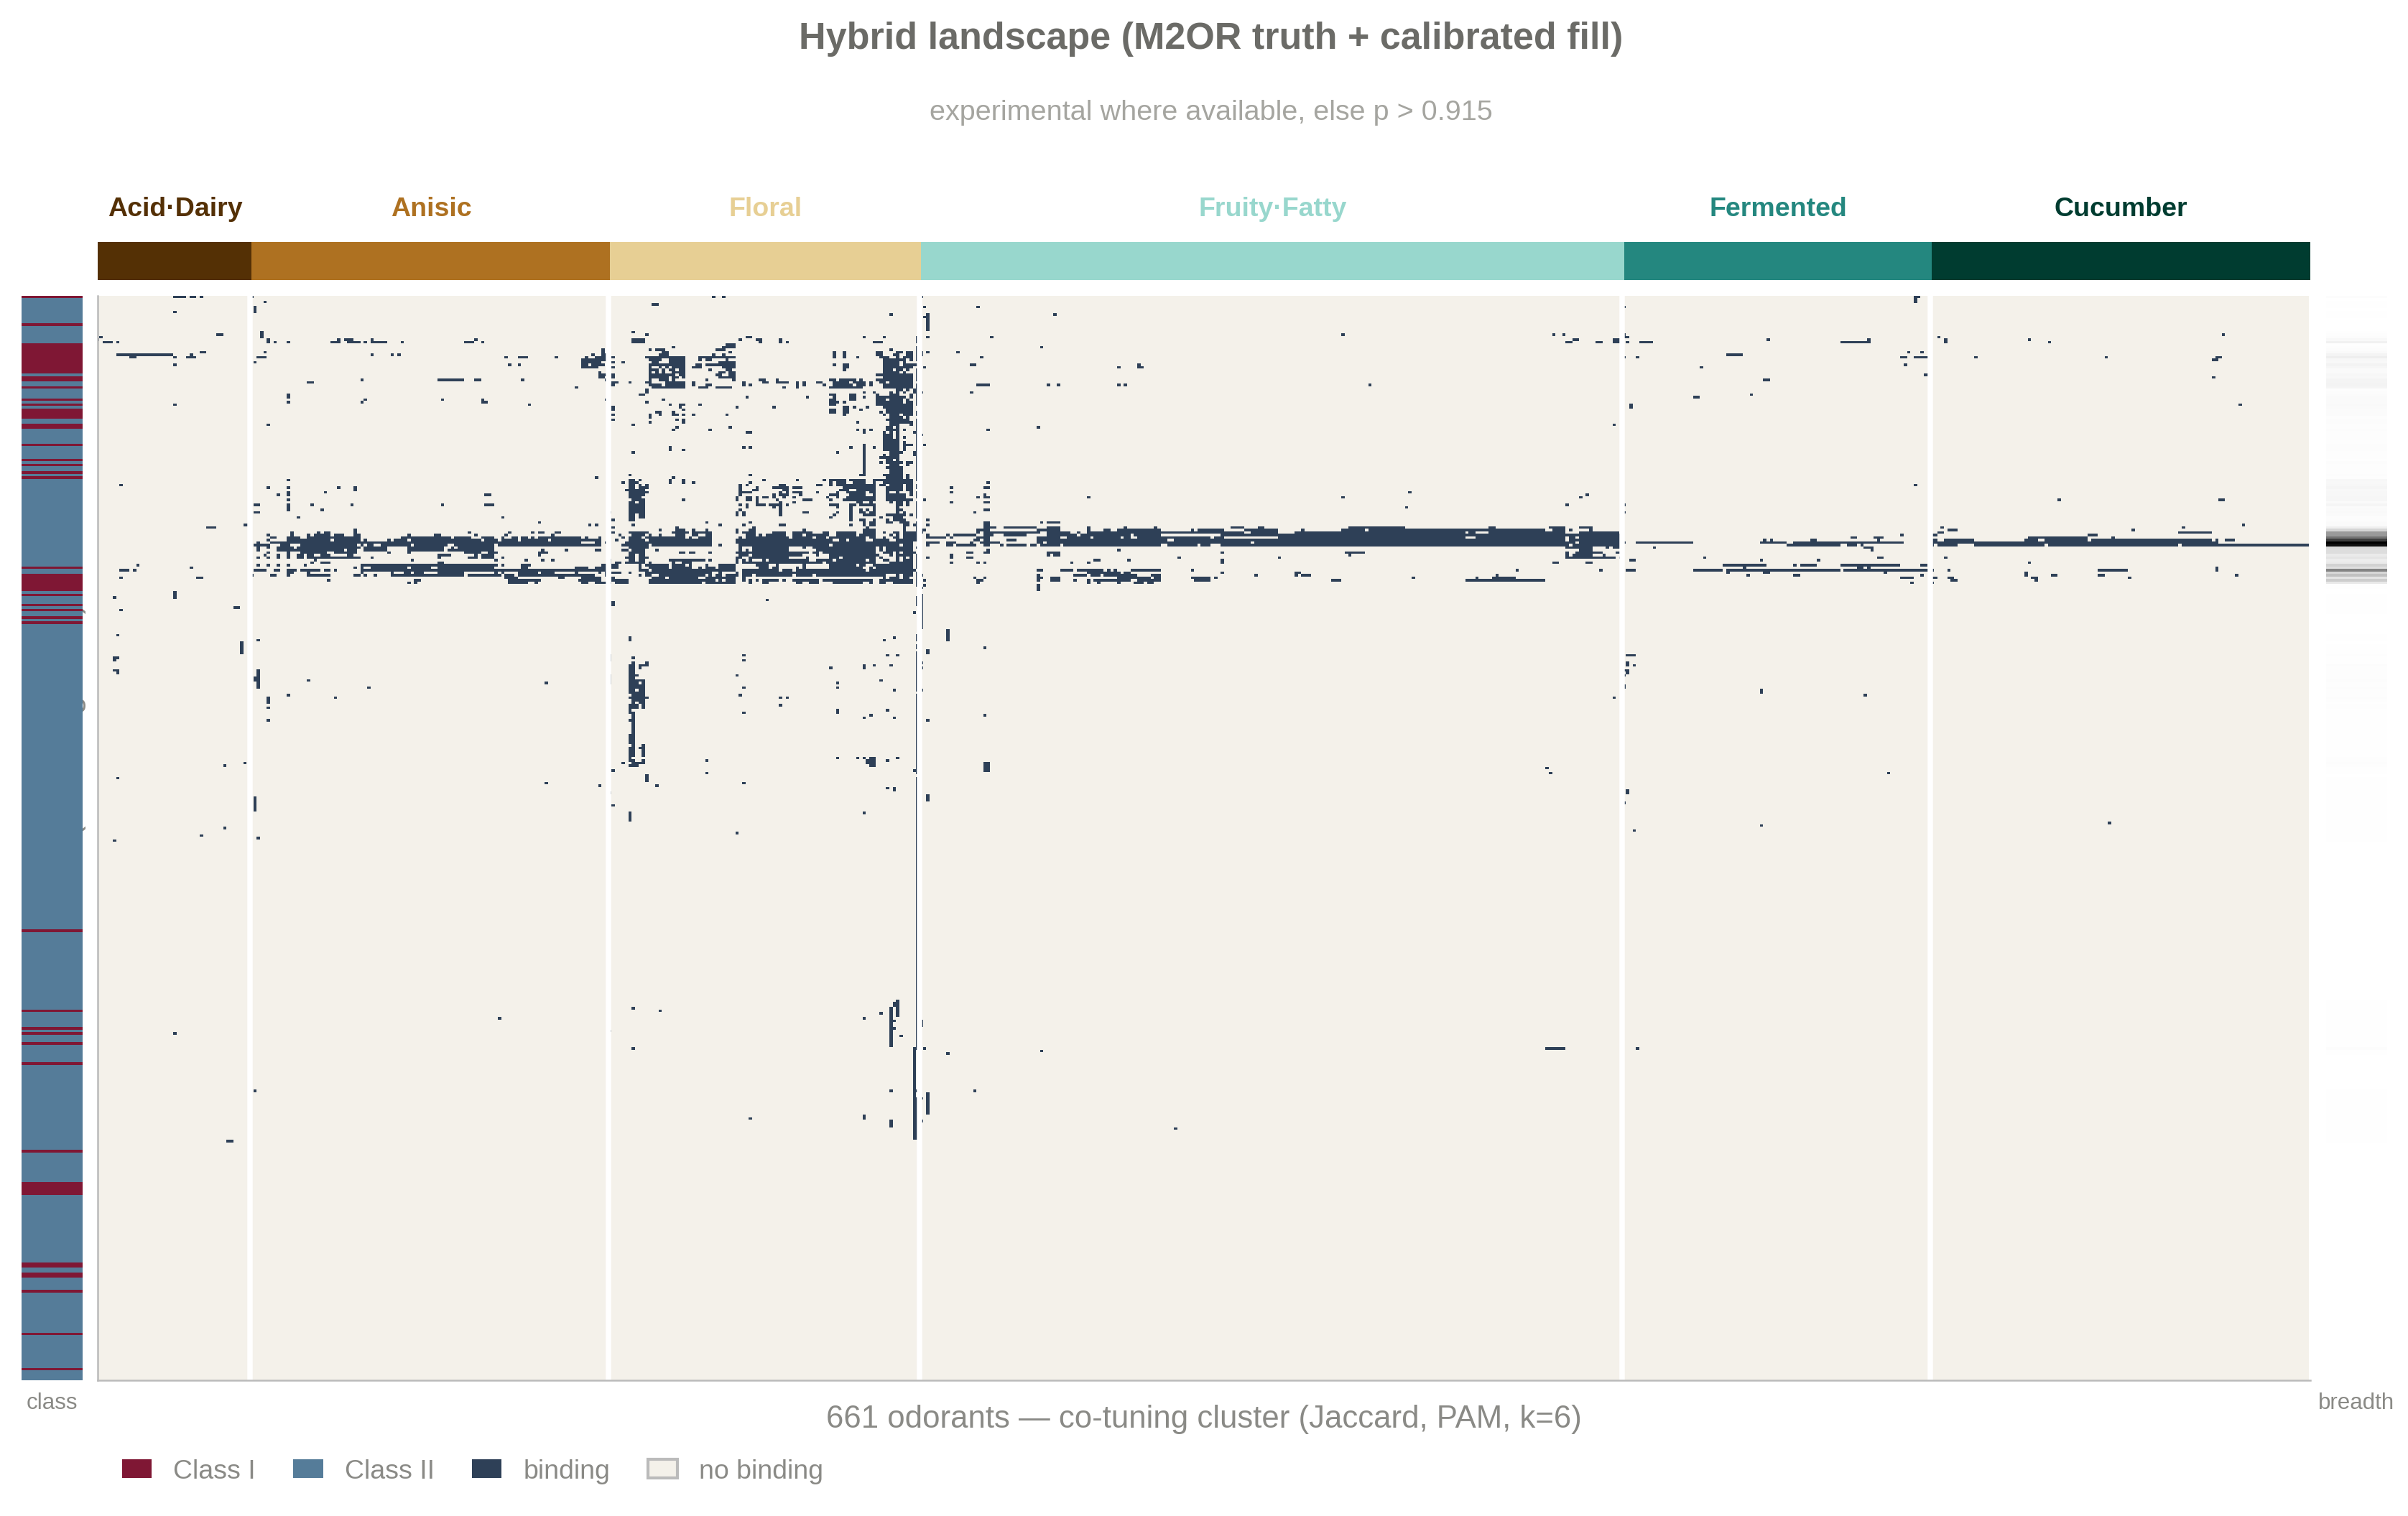

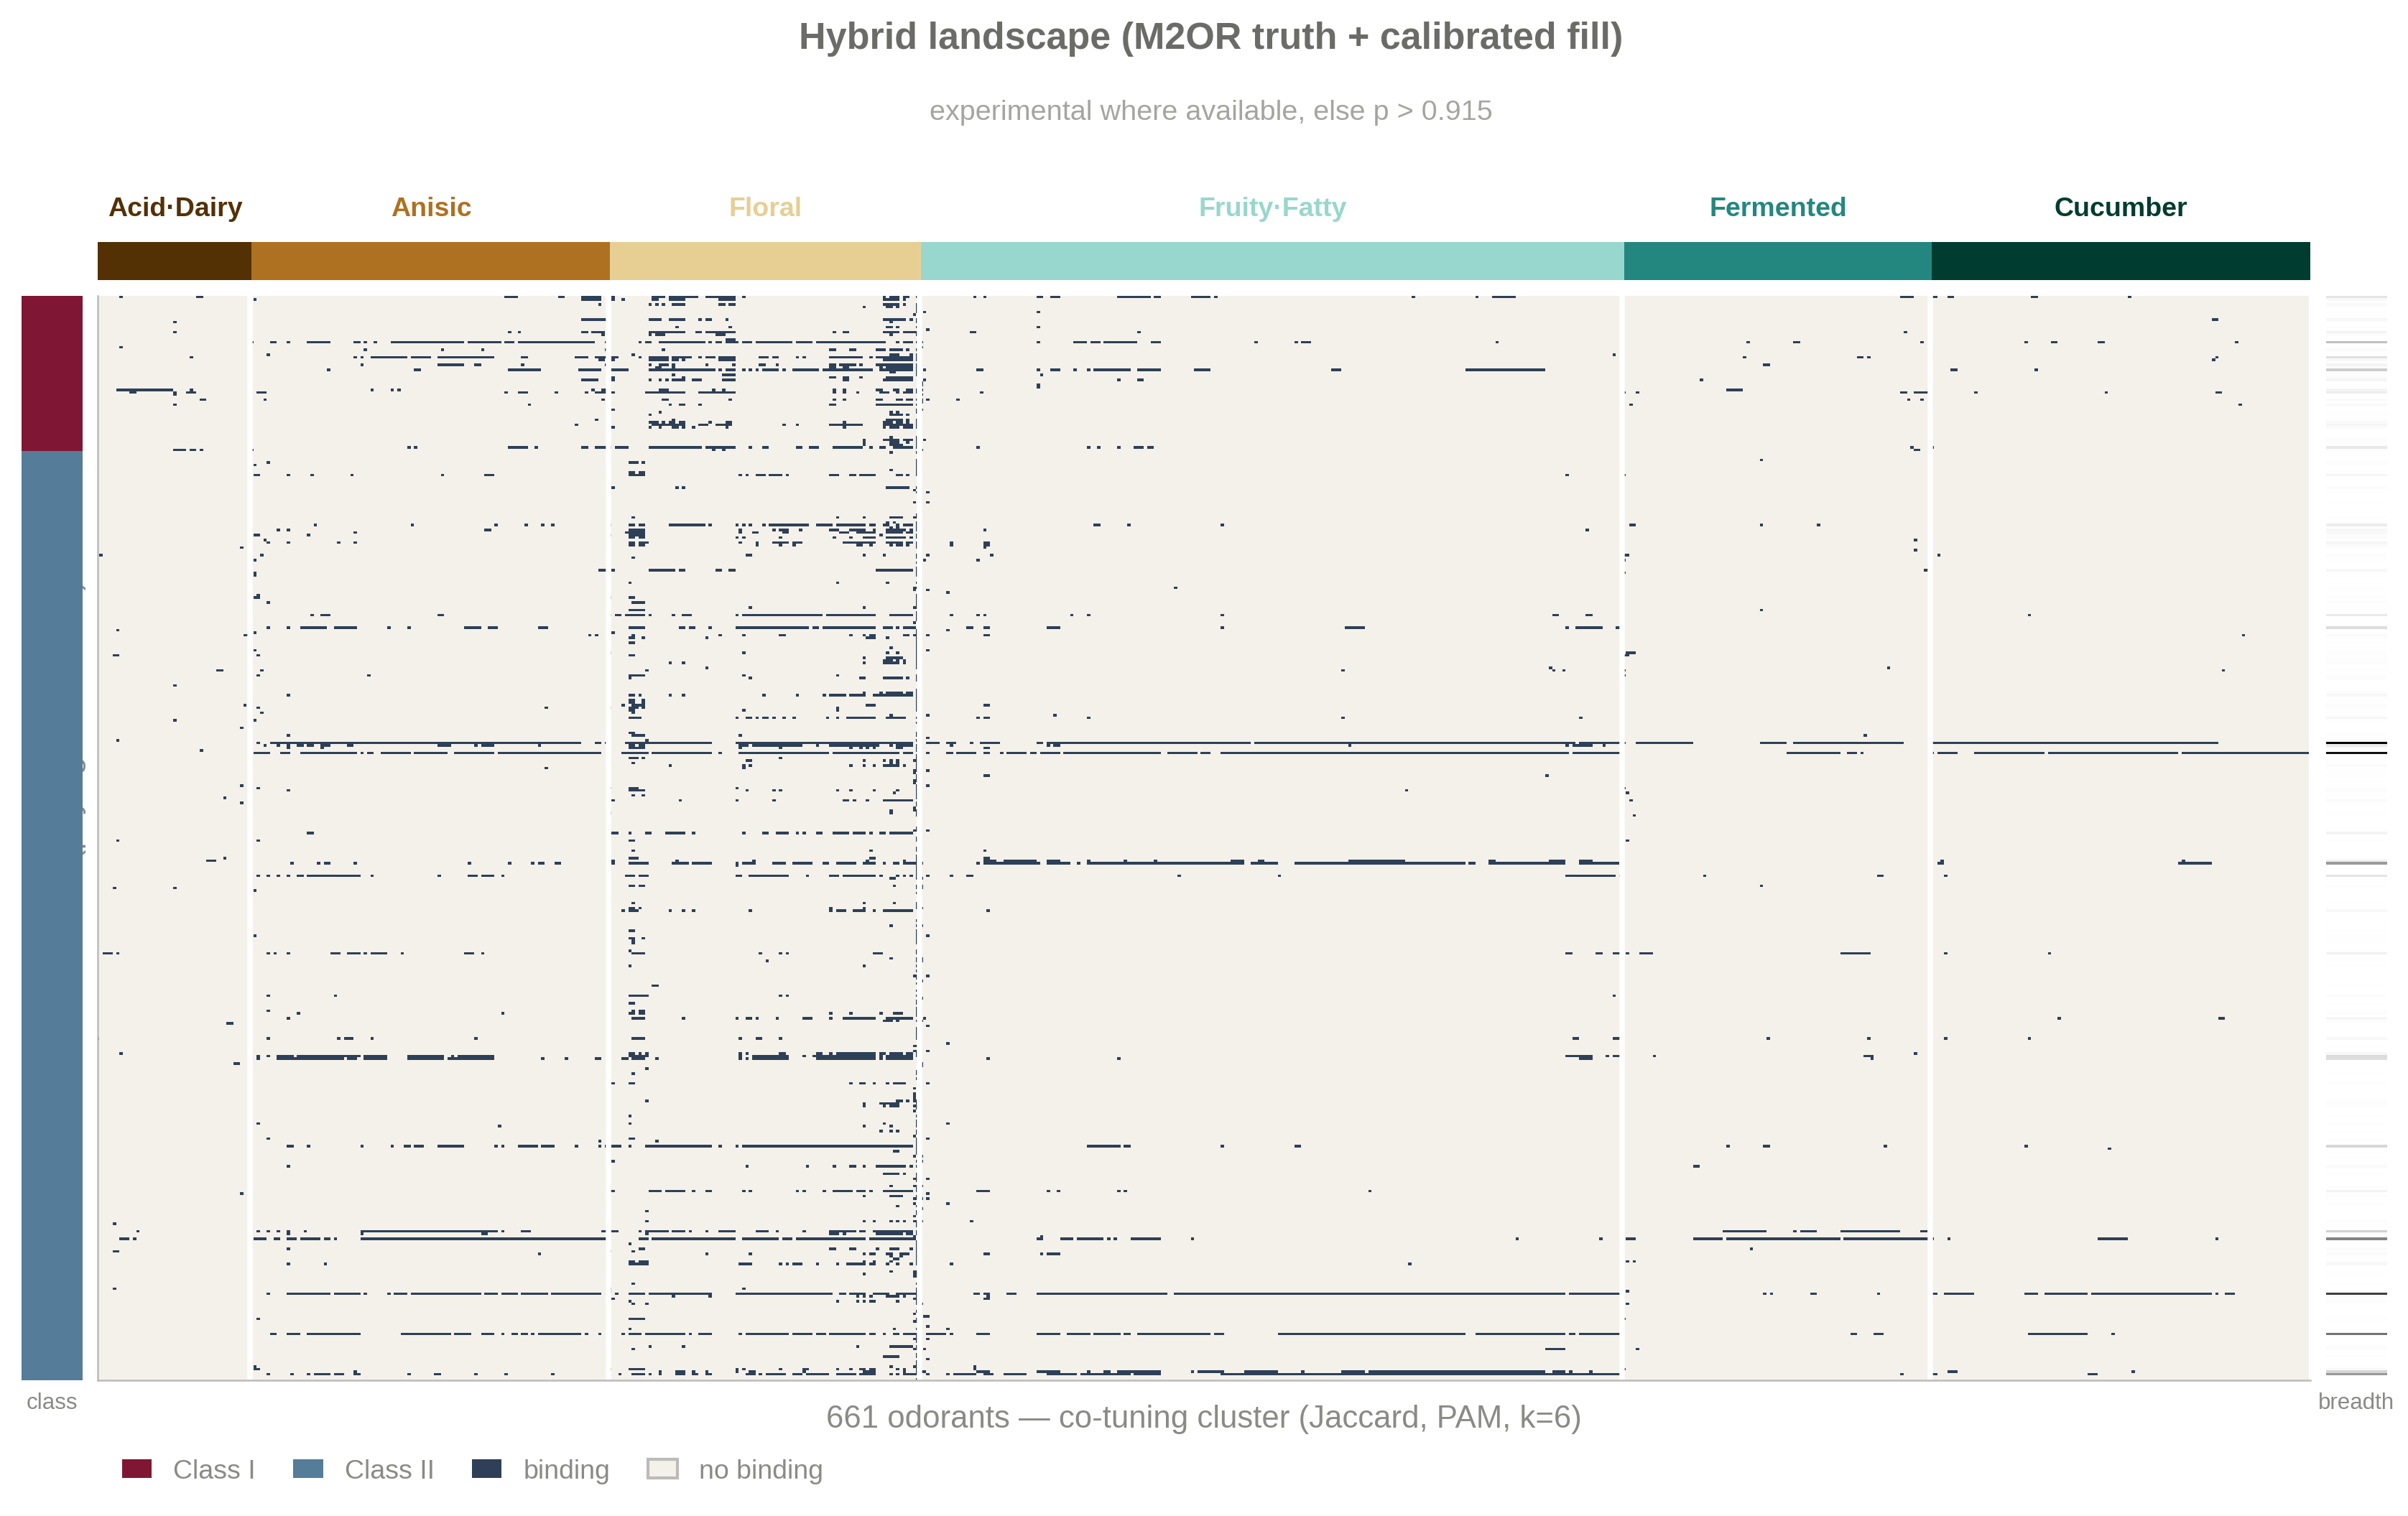

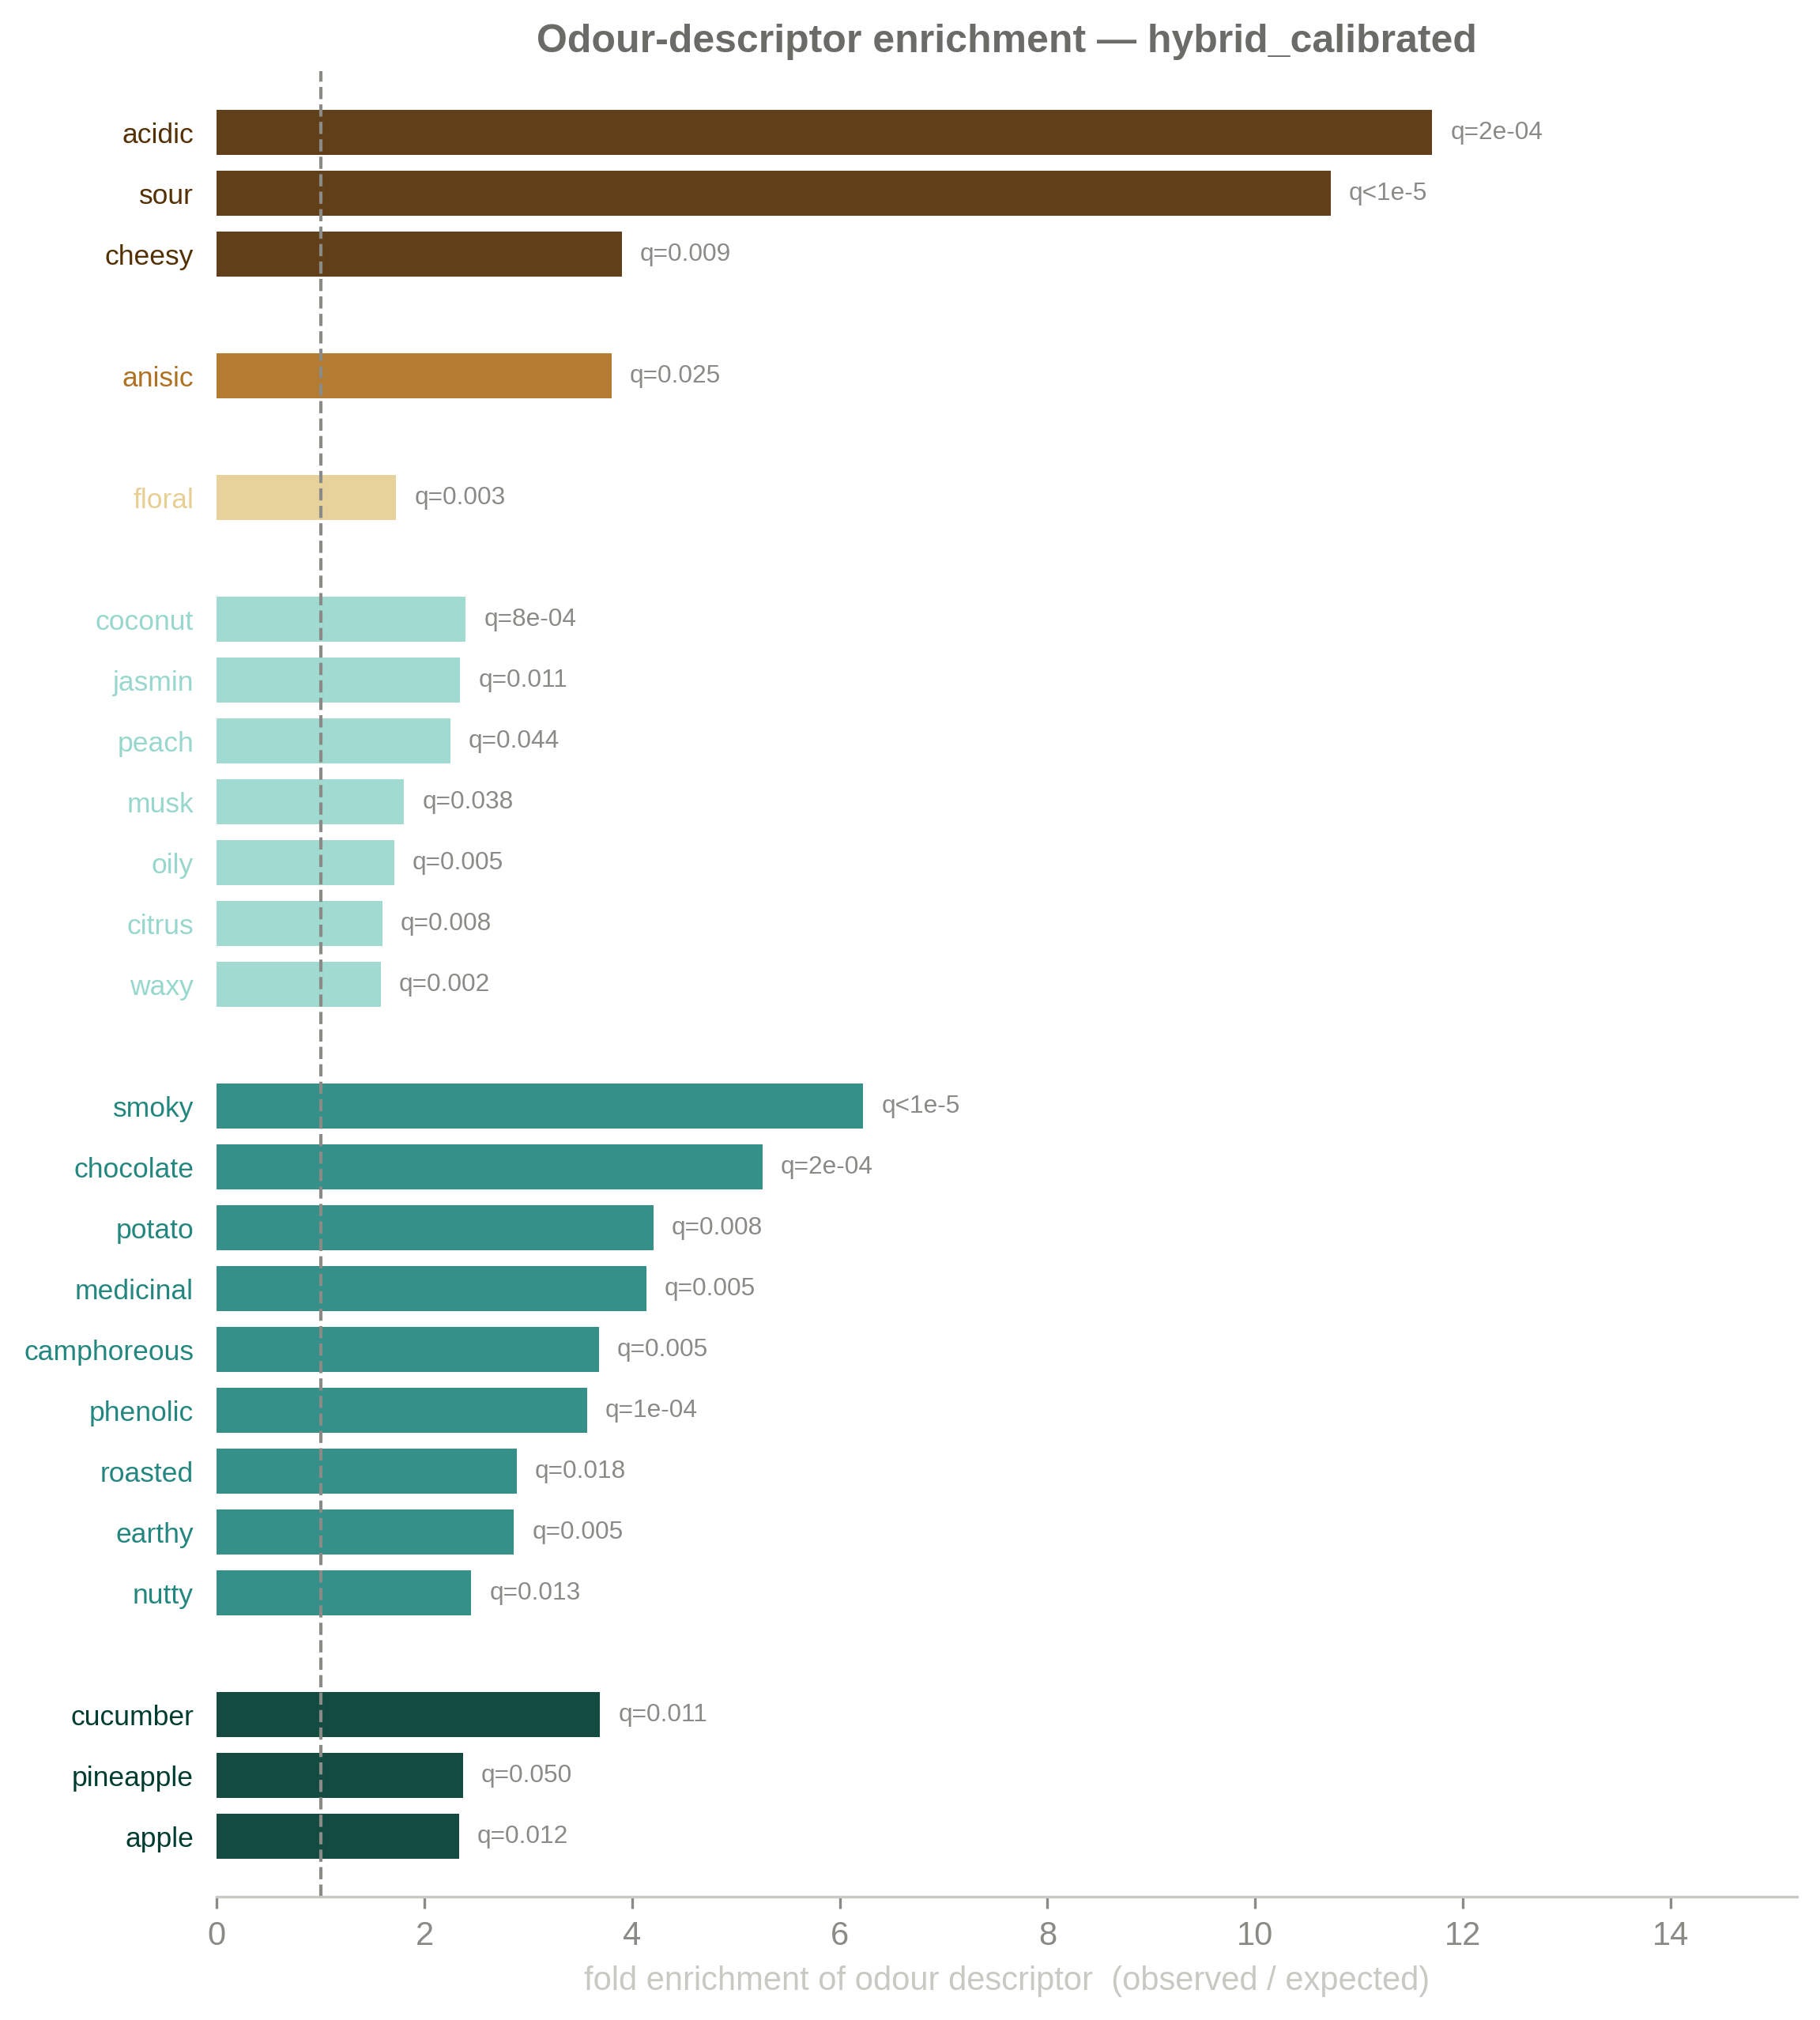

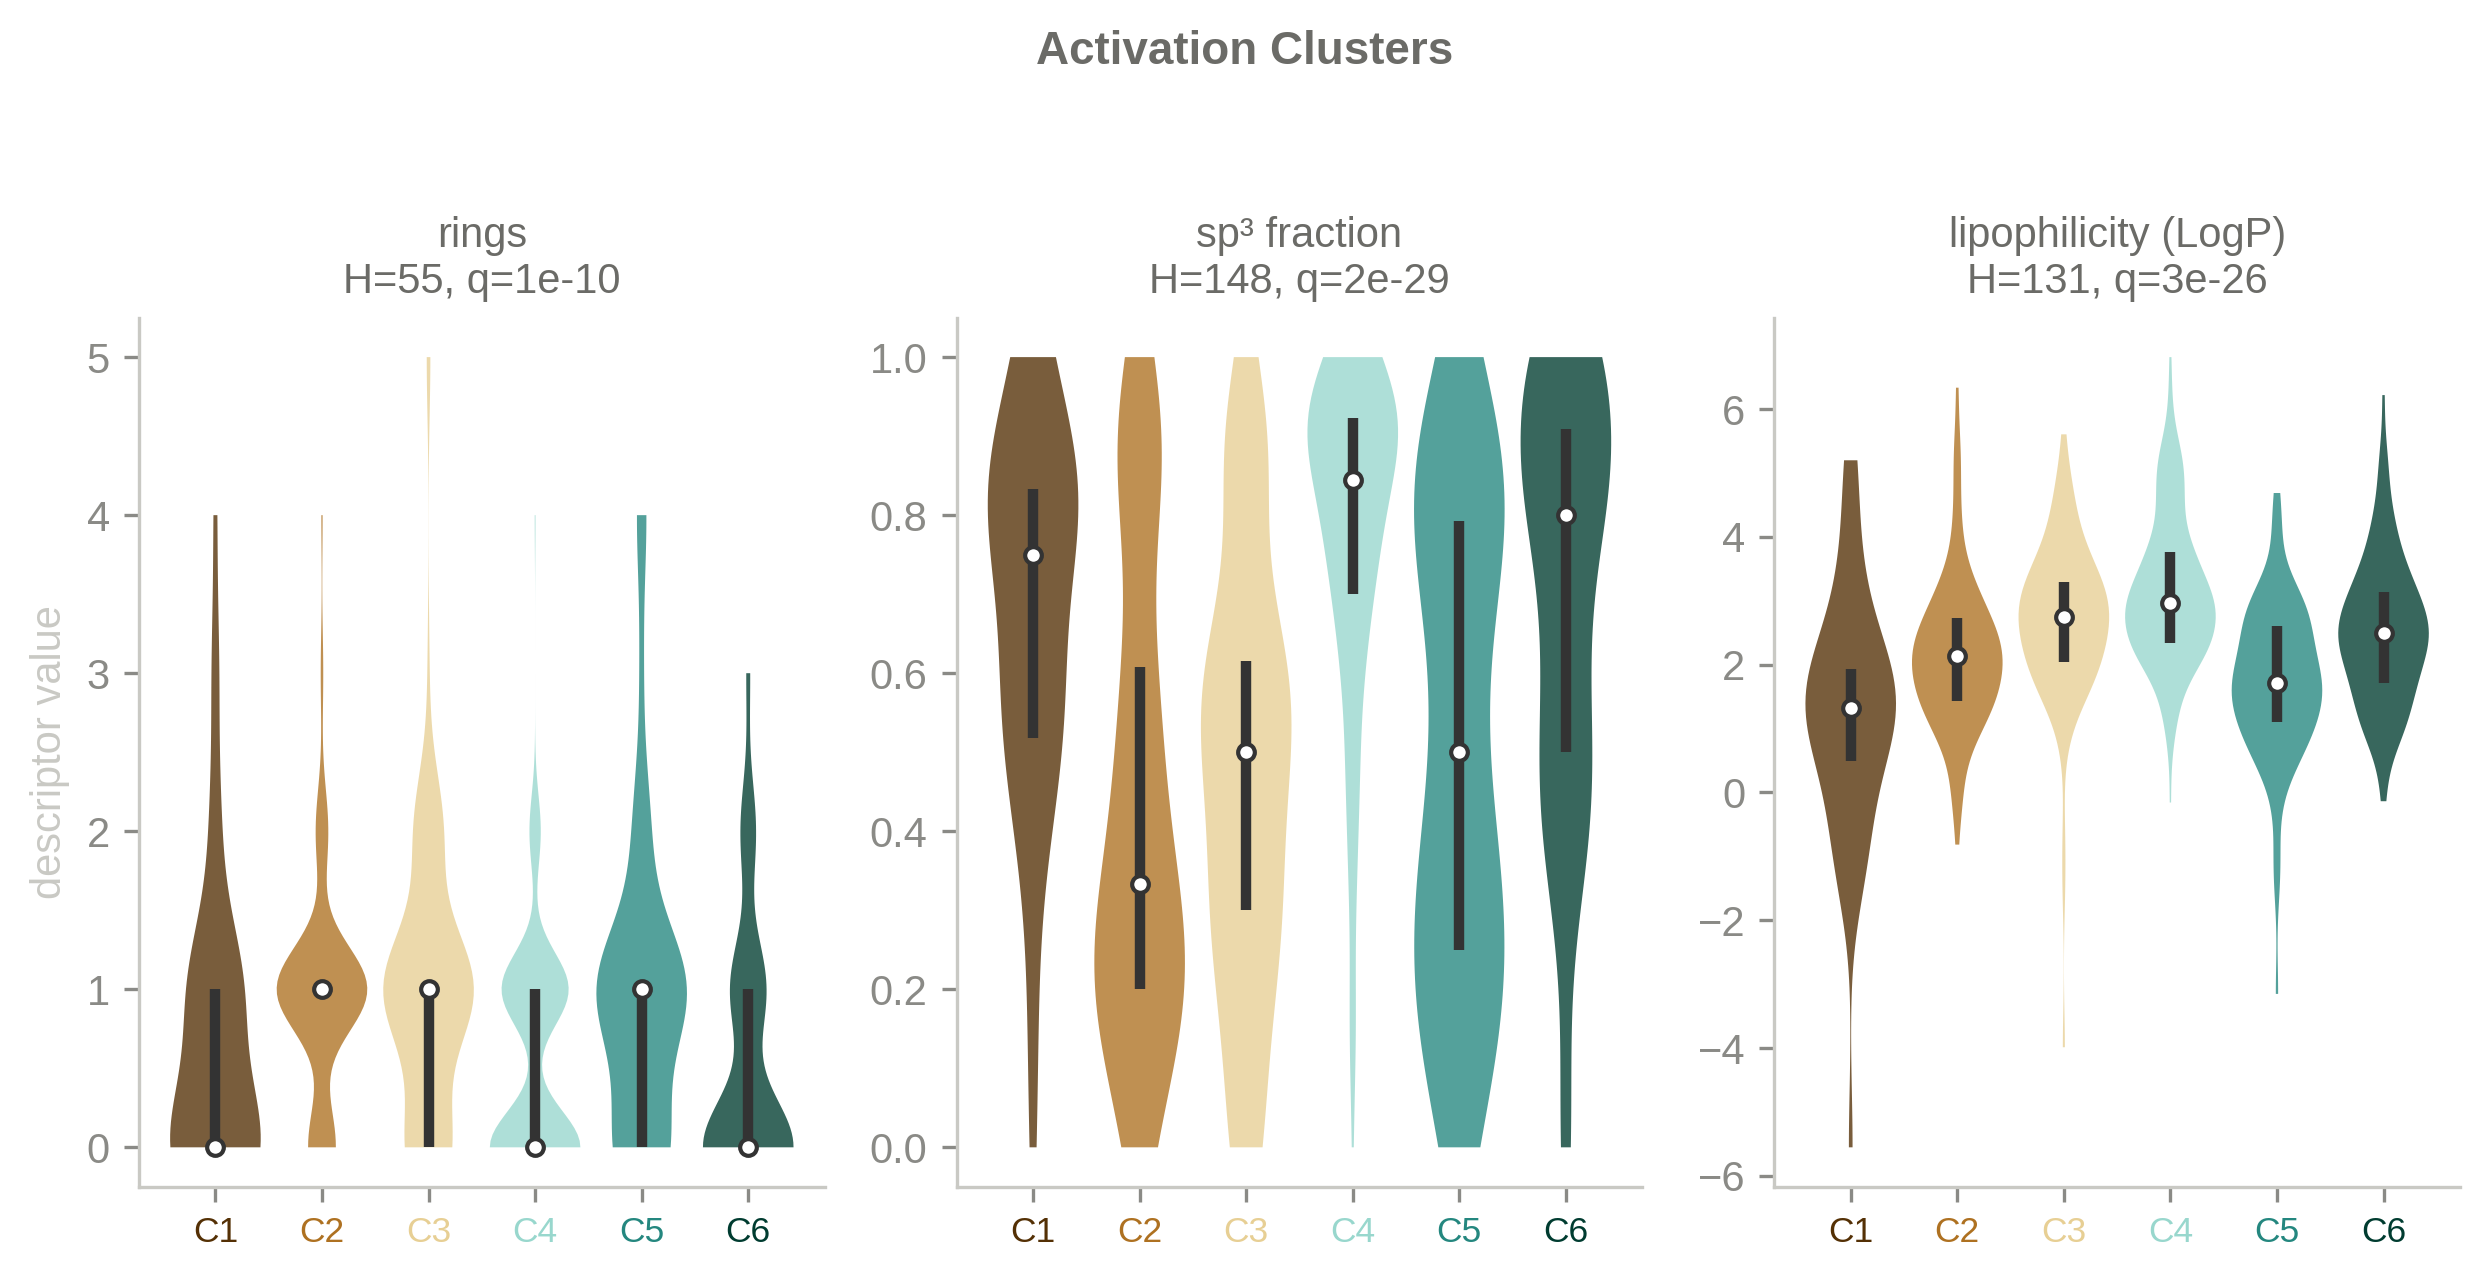

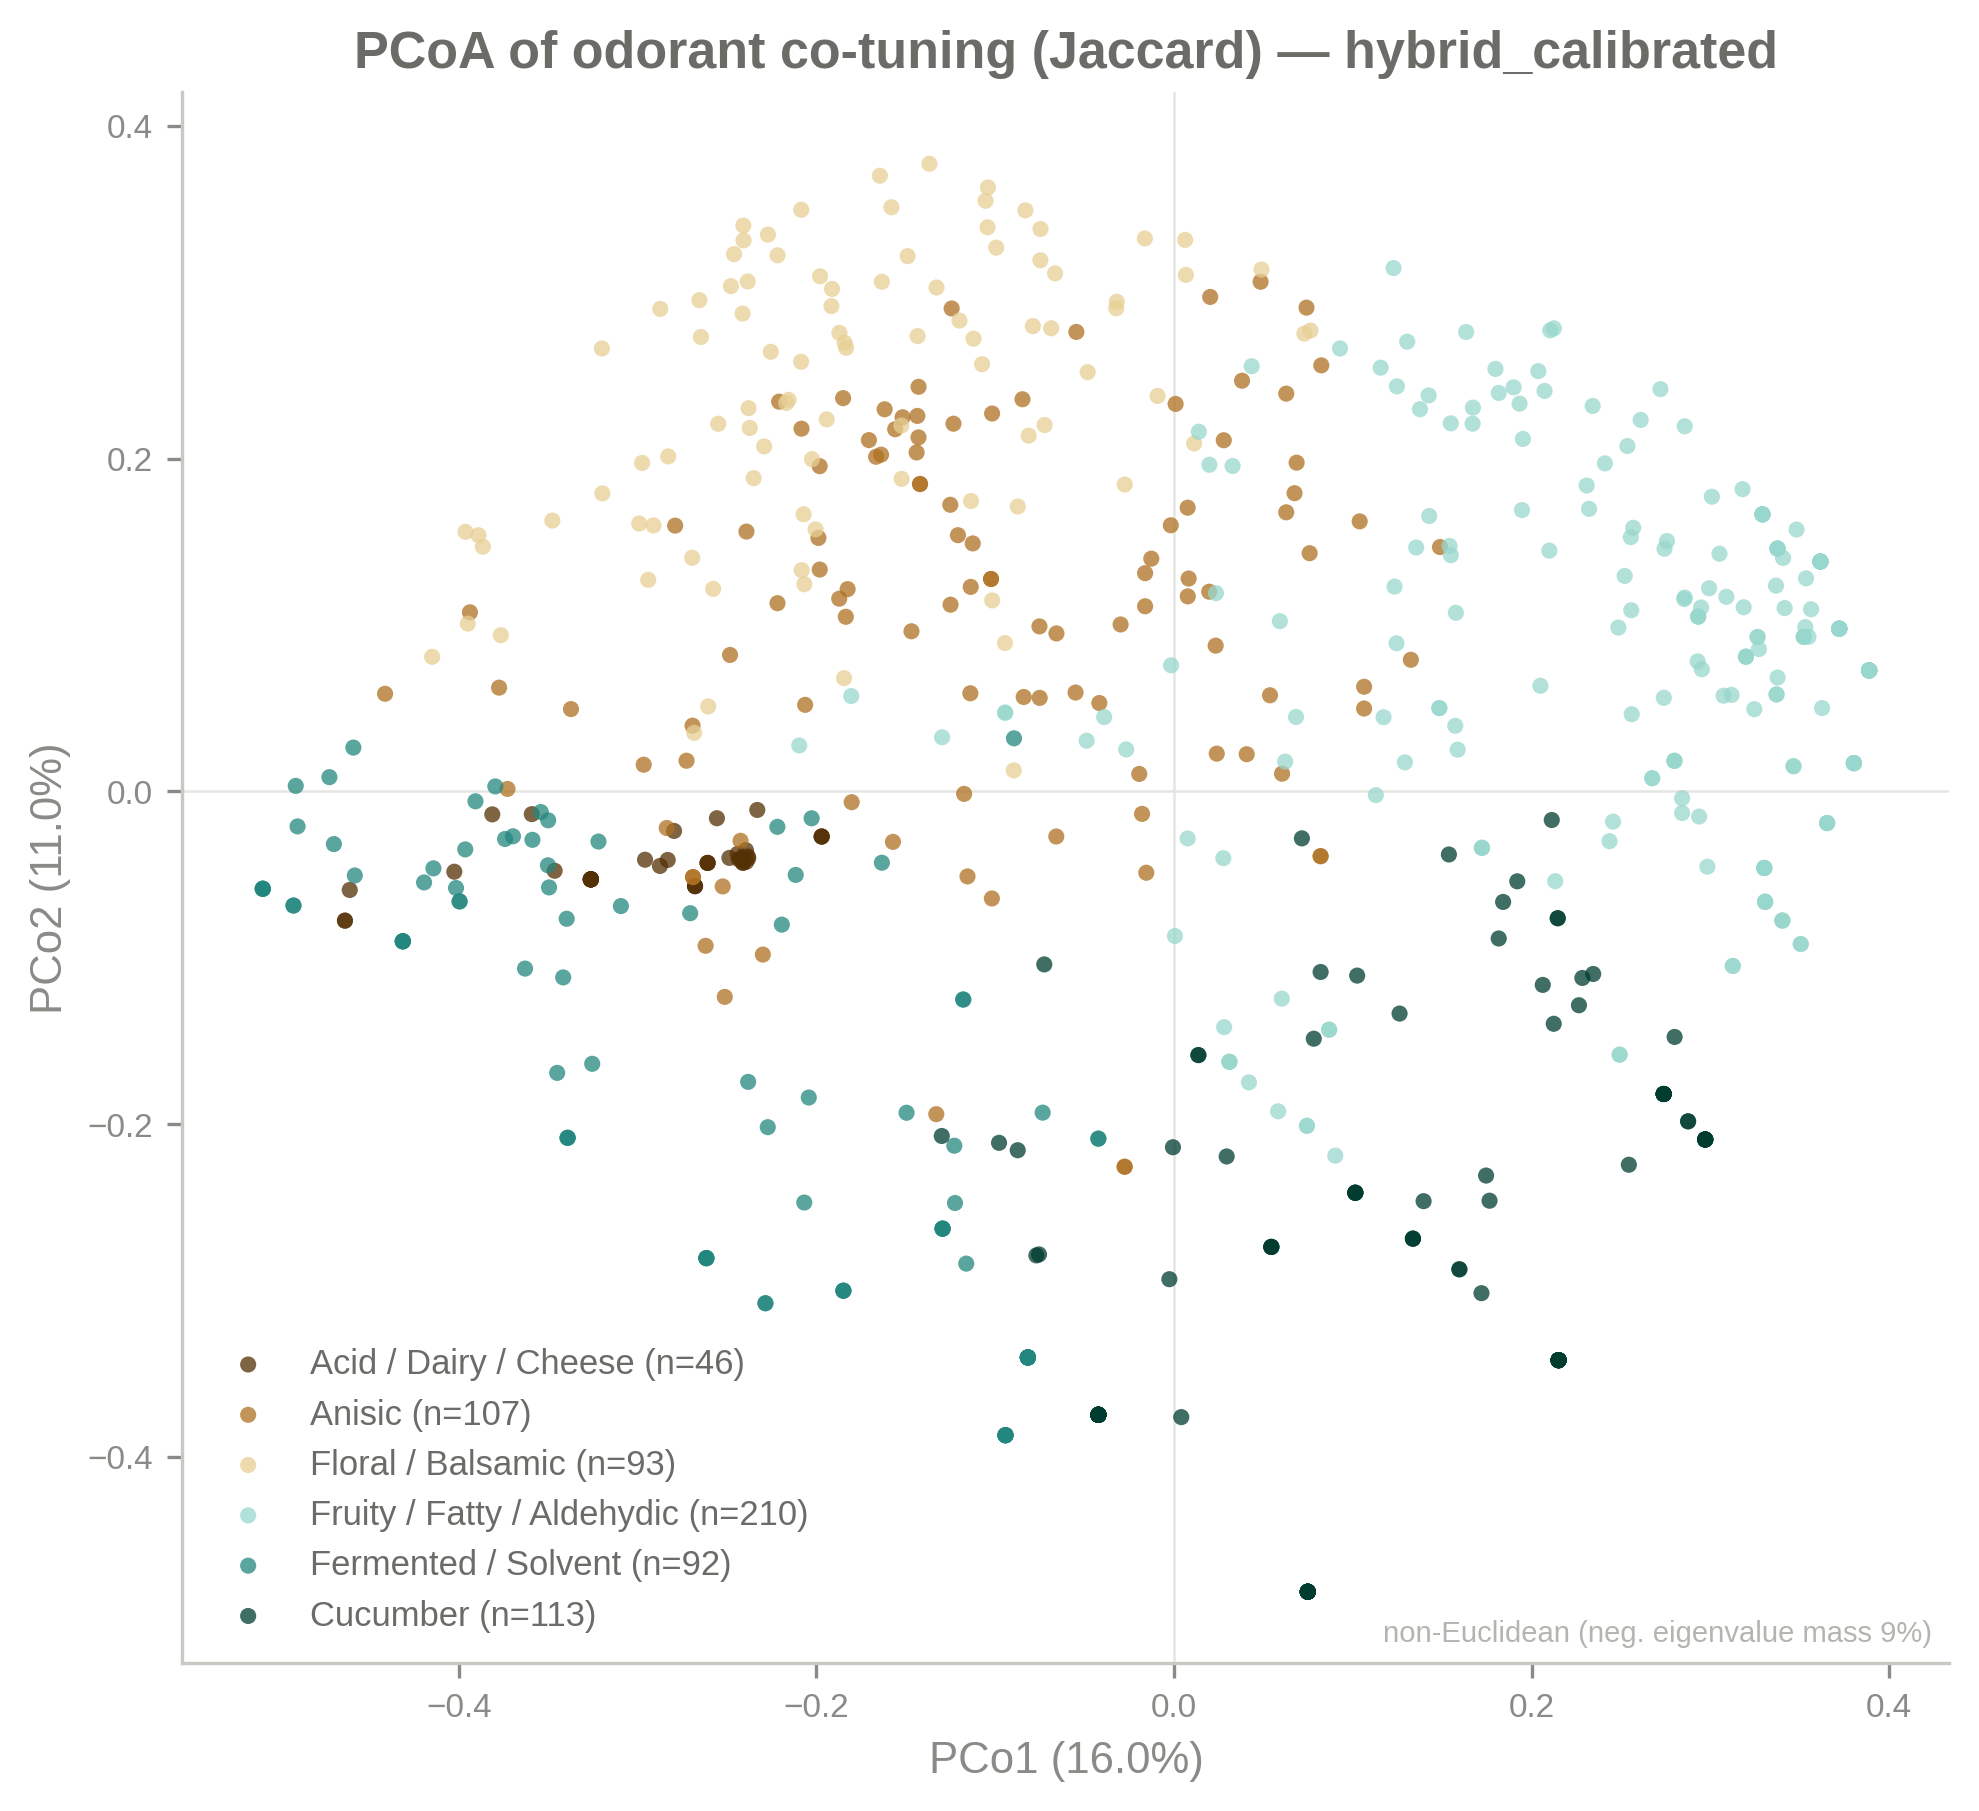

hybrid_calibrated sizes [210, 113, 107, 93, 92, 46]  #sig 24
baseline     sizes [184, 156, 132, 130, 84, 65]  #sig 37
calibrated   sizes [212, 136, 131, 66, 50, 40]  #sig 26
hybrid_baseline sizes [167, 150, 141, 123, 114, 57]  #sig 29


In [14]:
run_matrix('hybrid_calibrated', hybrid_calibrated,
           'Hybrid landscape (M2OR truth + calibrated fill)',
           f'experimental where available, else p > {CALIB_THR:.3f}', show=True)

run_matrix('baseline',   baseline,   'Baseline landscape (p ≥ 0.50)',
           'released prediction file', show=False)
run_matrix('calibrated', calibrated, f'Calibrated landscape (p > {CALIB_THR:.3f})',
           'high-confidence predictions', show=False)
run_matrix('hybrid_baseline', hybrid_baseline,
           'Hybrid landscape (M2OR truth + baseline fill)',
           'experimental where available, else p ≥ 0.50', show=False)

## 9 · Chemical space of Class I- vs Class II-preferring odorants

Computed on the hybrid_calibrated matrix only.

A molecule enters a class's bag when it activates at least `r = 1/62` of that class —
one Class I receptor, or six Class II receptors. Equal rates rather than equal counts,
so the 62/371 class-size difference does not decide membership. That yields three sets:
the two exclusive ones, which the tests compare, and the shared set, reported as the
generalist core both classes read.

chemspace hybrid_calibrated r=0.0161  I only=115  shared=218  II only=113  |  below r in both=215  unbound=93


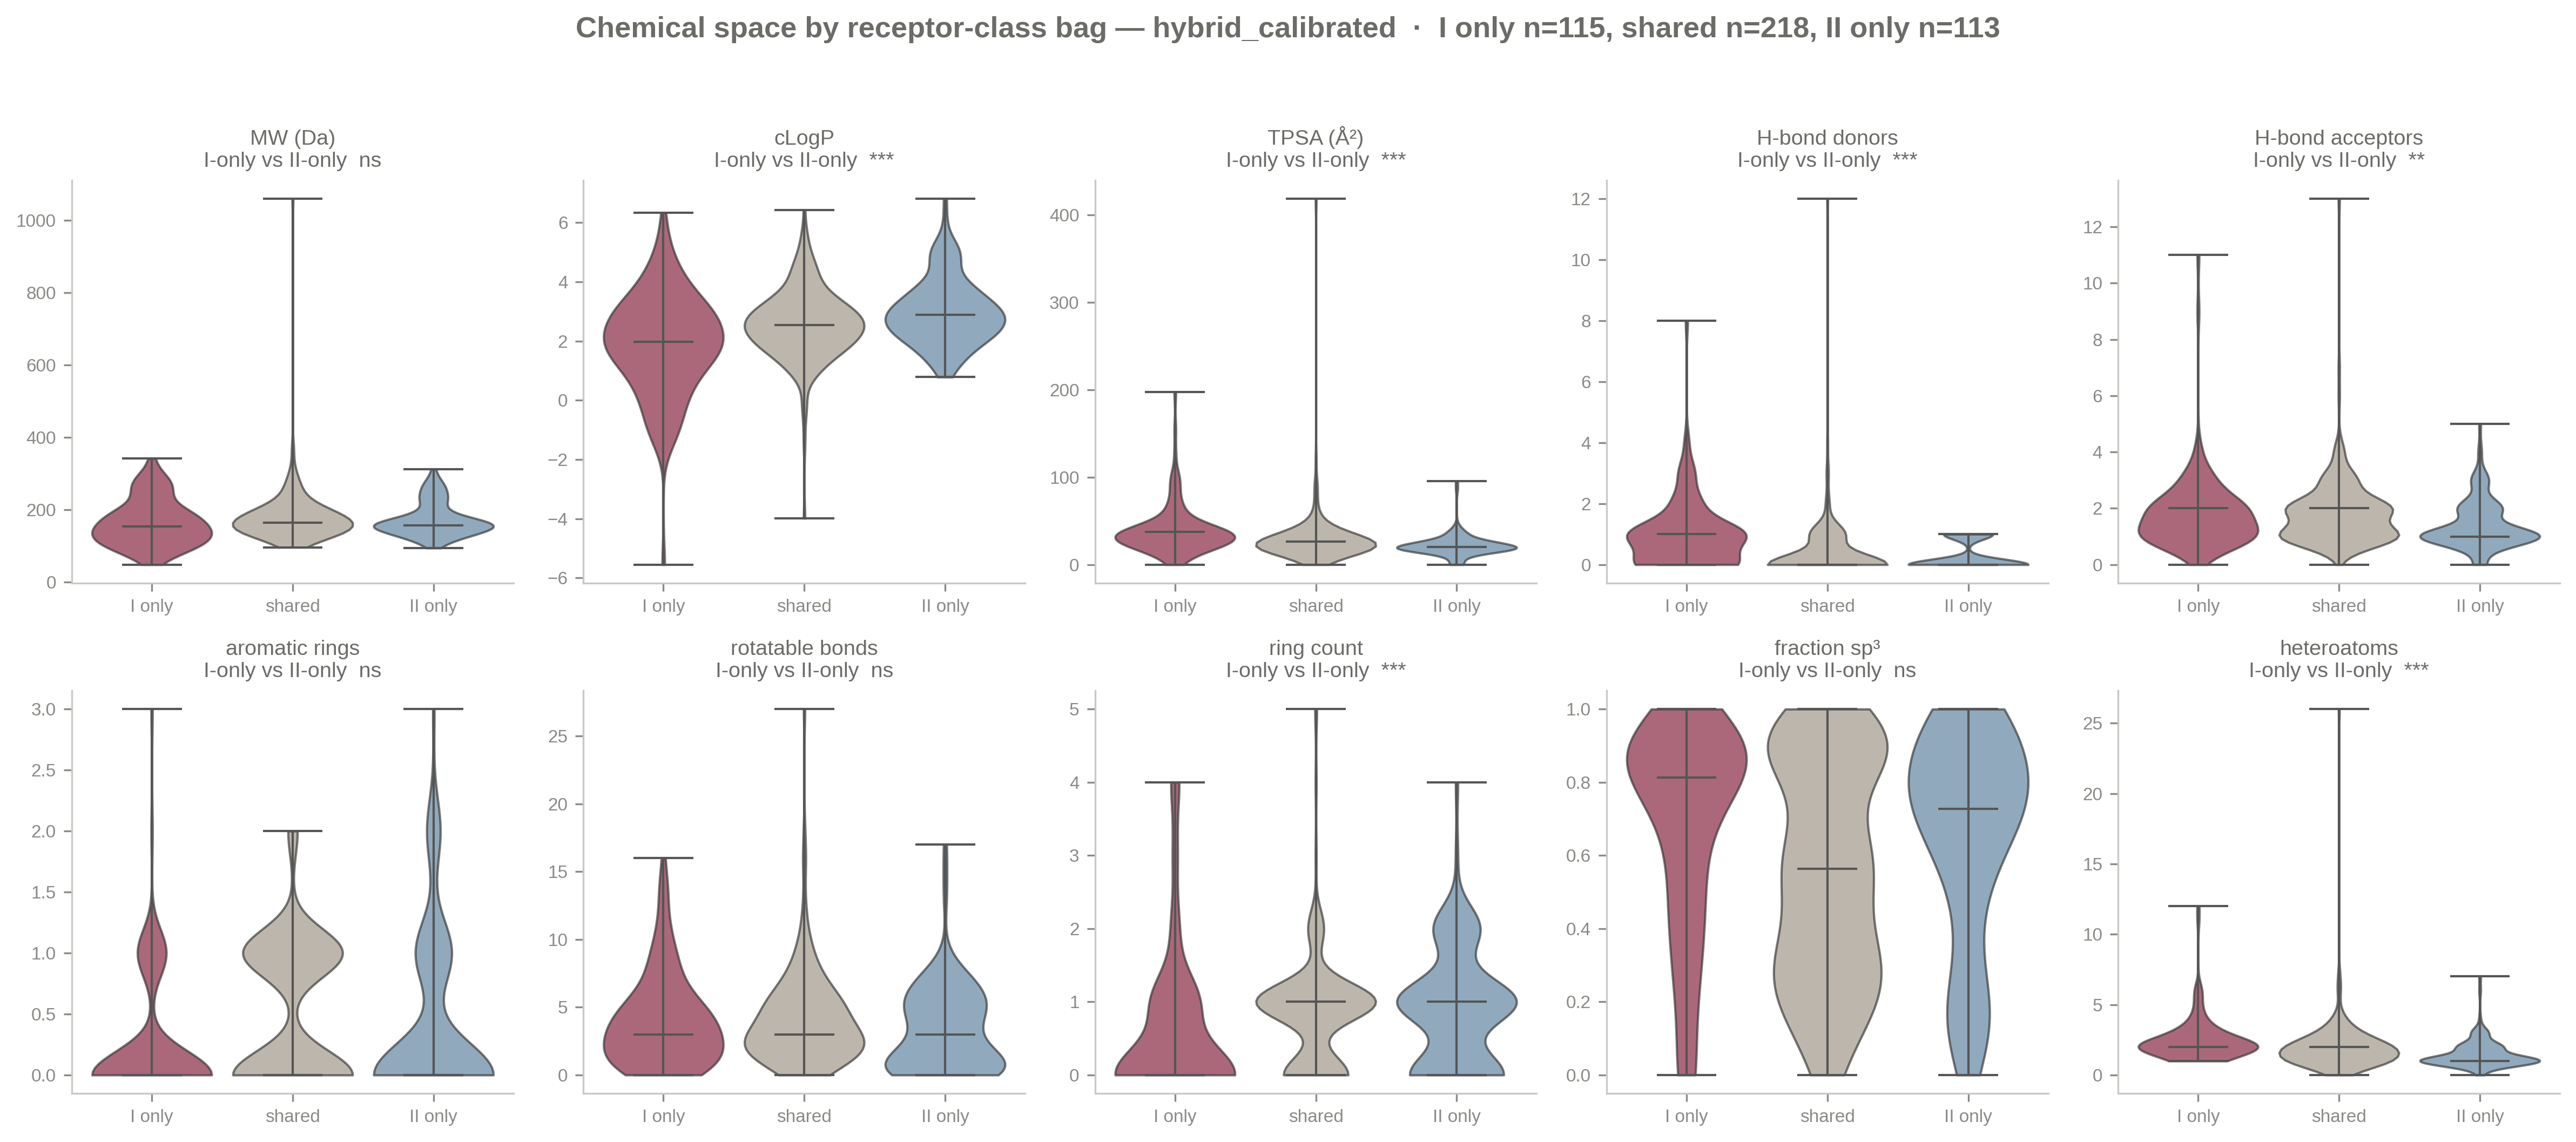

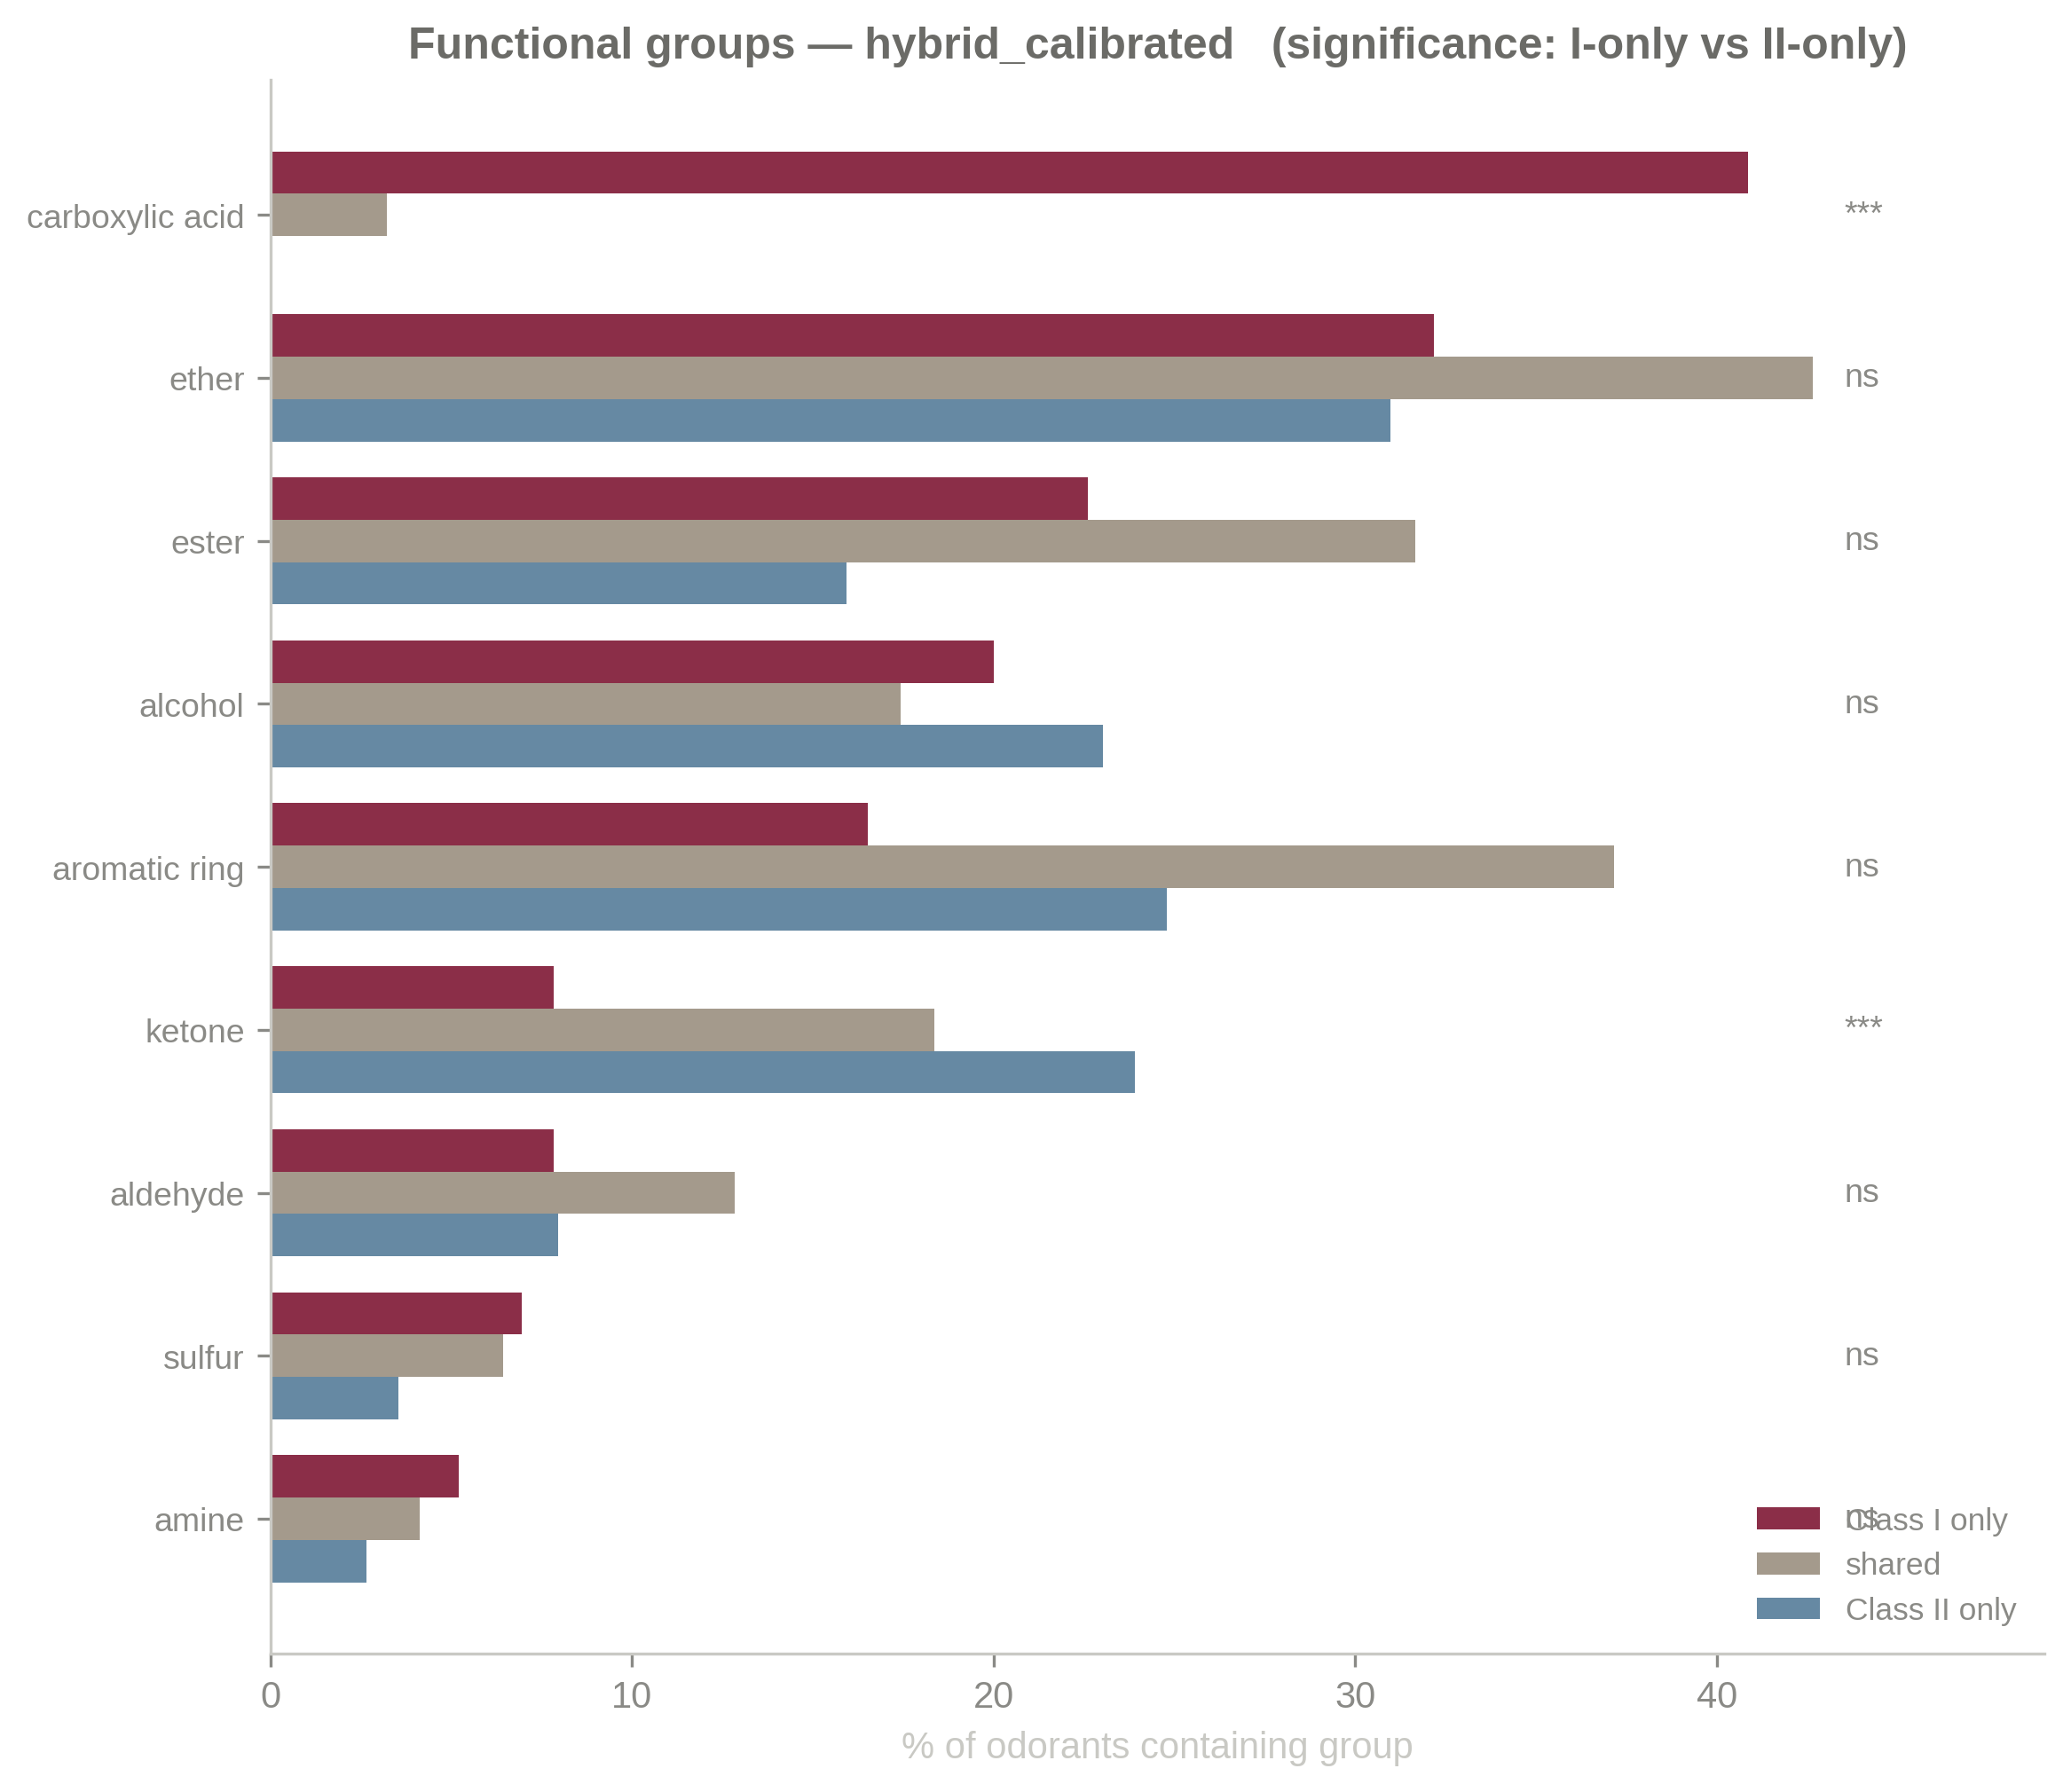

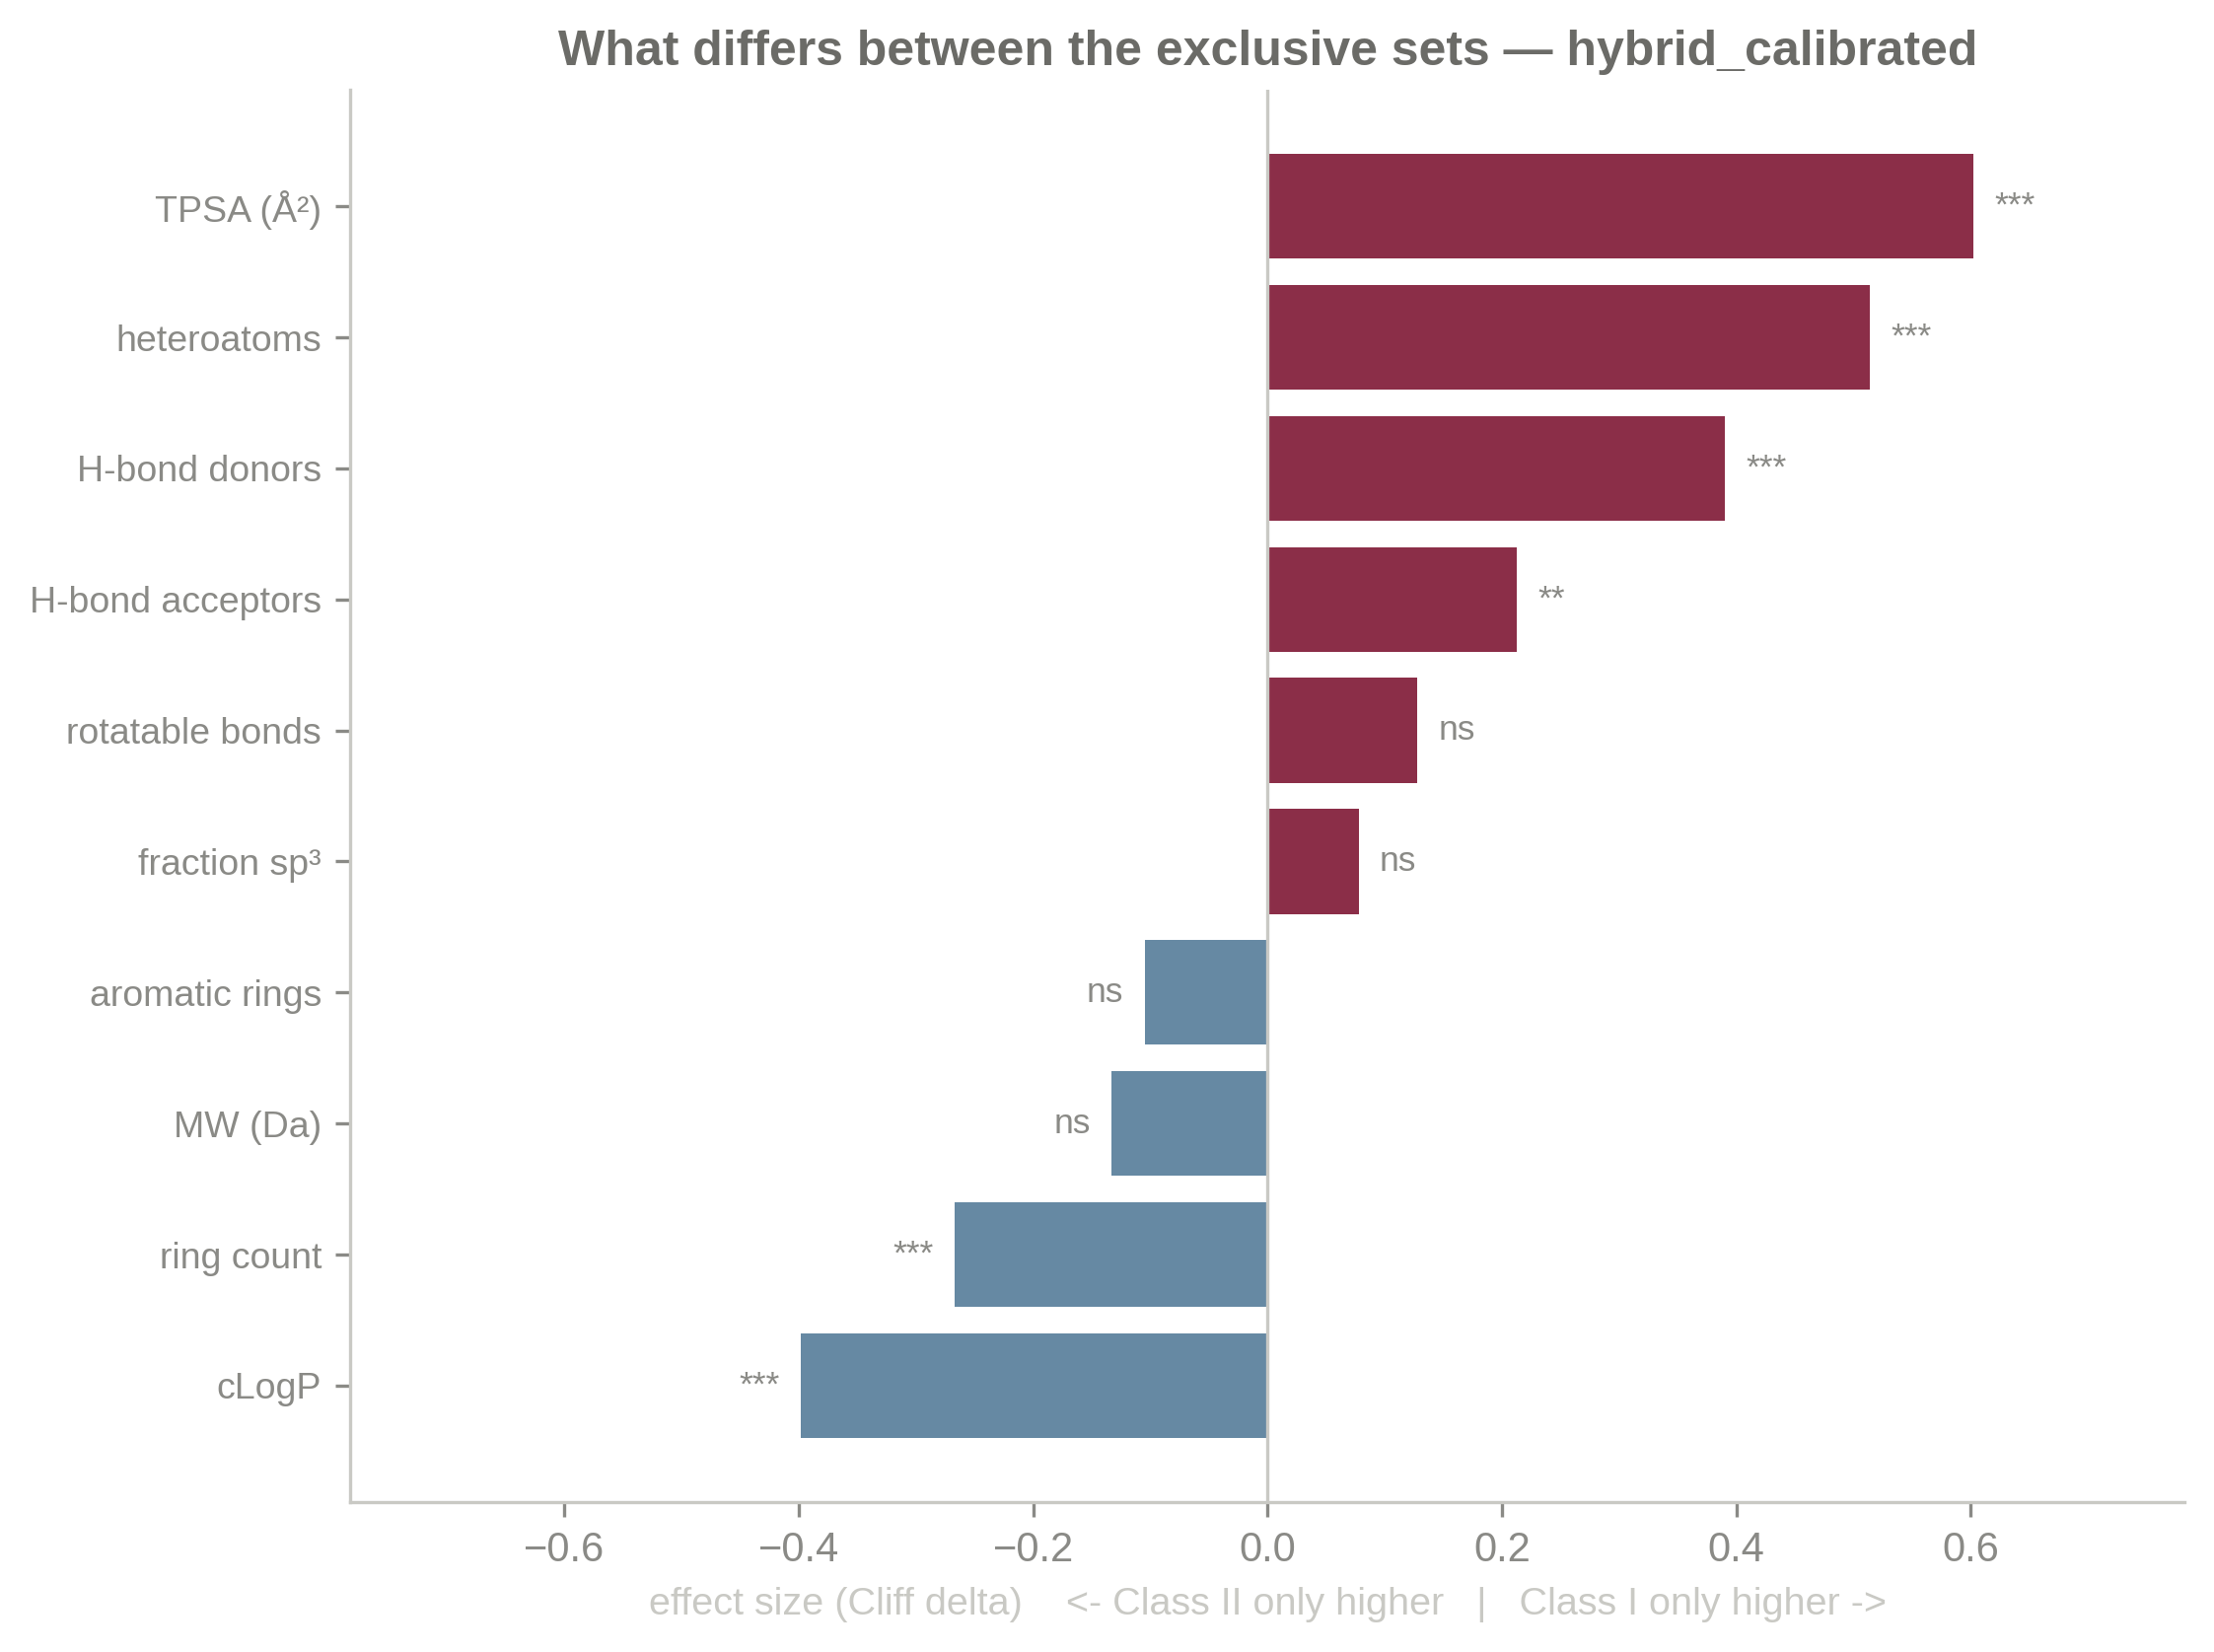

In [15]:
_FG={'carboxylic acid':'[CX3](=O)[OX2H1]','ester':'[CX3](=O)[OX2H0][#6]','aldehyde':'[CX3H1](=O)[#6]',
     'ketone':'[#6][CX3](=O)[#6]','alcohol':'[#6;!$([CX3]=O)][OX2H1]','ether':'[OD2]([#6])[#6]',
     'aromatic ring':'c1ccccc1','amine':'[NX3;!$([NX3][CX3]=[OX1])]','sulfur':'[#16]'}
_FGP={k:Chem.MolFromSmarts(v) for k,v in _FG.items()}
SHARED_COL='#9a8f80'
GRP_ORDER=['Class I only','shared','Class II only']
GRP_COL={'Class I only':CLASS_I_COL,'shared':SHARED_COL,'Class II only':CLASS_II_COL}


def class_partition(Xbind,rate=None):
    """Three-way split of odorants by binding rate within each receptor class."""
    isI=np.array([pid2class[p]=='I' for p in hum_pids]); isII=~isI
    NI,NII=isI.sum(),isII.sum()
    r0=1.0/NI if rate is None else rate
    rI=Xbind[isI].sum(0)/NI; rII=Xbind[isII].sum(0)/NII
    bI,bII=rI>=r0,rII>=r0
    grp=np.full(len(lig_cols),'',dtype=object)
    grp[bI&~bII]='Class I only'; grp[bI&bII]='shared'; grp[~bI&bII]='Class II only'
    return grp,r0,rI,rII


def chemical_space(Xbind,name,rate=None):
    grp,r0,rI,rII=class_partition(Xbind,rate)
    recs=[]
    for j,sid in enumerate(lig_cols):
        if not grp[j]: continue
        sm=sml2smiles.get(sid); mol=Chem.MolFromSmiles(sm) if isinstance(sm,str) else None
        if mol is None: continue
        d=dict(sml=sid,group=grp[j],rate_I=rI[j],rate_II=rII[j],
            MolWt=Descriptors.MolWt(mol),LogP=Crippen.MolLogP(mol),TPSA=rdMolDescriptors.CalcTPSA(mol),
            HBD=Lipinski.NumHDonors(mol),HBA=Lipinski.NumHAcceptors(mol),
            AromaticRings=rdMolDescriptors.CalcNumAromaticRings(mol),
            RotBonds=Descriptors.NumRotatableBonds(mol),RingCount=rdMolDescriptors.CalcNumRings(mol),
            FracCSP3=rdMolDescriptors.CalcFractionCSP3(mol),Heteroatoms=Lipinski.NumHeteroatoms(mol))
        for g,patt in _FGP.items(): d[g]=int(mol.HasSubstructMatch(patt))
        recs.append(d)
    df=pd.DataFrame(recs); df.to_csv(f'{OUTDIR}/chemspace_{name}_descriptors.csv',index=False)
    G={g:df[df.group==g] for g in GRP_ORDER}
    n={g:len(G[g]) for g in GRP_ORDER}
    unbound=int((Xbind.sum(0)==0).sum())
    weak=int((grp=='').sum())-unbound          # bound, but below r in both classes
    print('chemspace %-17s r=%.4f  I only=%d  shared=%d  II only=%d  |  below r in both=%d  unbound=%d'
          %(name,r0,n['Class I only'],n['shared'],n['Class II only'],weak,unbound))

    props=[('MolWt','MW (Da)'),('LogP','cLogP'),('TPSA','TPSA (Å²)'),('HBD','H-bond donors'),
           ('HBA','H-bond acceptors'),('AromaticRings','aromatic rings'),('RotBonds','rotatable bonds'),
           ('RingCount','ring count'),('FracCSP3','fraction sp³'),('Heteroatoms','heteroatoms')]

    # (a) descriptor violins; p compares the two EXCLUSIVE sets, which are disjoint
    fig,axes=plt.subplots(2,5,figsize=(16,7)); axes=axes.ravel()
    for ax,(k,lab) in zip(axes,props):
        data=[G[g][k].values for g in GRP_ORDER]
        parts=ax.violinplot(data,showmedians=True,widths=0.85)
        for pc,g in zip(parts['bodies'],GRP_ORDER): pc.set_facecolor(GRP_COL[g]); pc.set_alpha(0.65); pc.set_edgecolor('#333')
        for key in ['cmedians','cmaxes','cmins','cbars']: parts[key].set_color('#555'); parts[key].set_linewidth(1.0)
        try: p=mannwhitneyu(G['Class I only'][k].values,G['Class II only'][k].values).pvalue
        except Exception: p=np.nan
        s='***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
        ax.set_title('%s\nI-only vs II-only  %s'%(lab,s),fontsize=9.5,color='#6b6b67')
        ax.set_xticks([1,2,3]); ax.set_xticklabels(['I only','shared','II only'],fontsize=8)
        ax.tick_params(axis='y',labelsize=8)
        for sp in ['top','right']: ax.spines[sp].set_visible(False)
    fig.suptitle('Chemical space by receptor-class bag — %s  ·  I only n=%d, shared n=%d, II only n=%d'
                 %(name,n['Class I only'],n['shared'],n['Class II only']),
                 fontsize=13,fontweight='bold',y=1.0,color='#6b6b67')
    fig.tight_layout(rect=[0,0,1,0.97]); save(fig,f'chemspace_{name}')

    # (b) functional groups; Fisher on the exclusive sets, shared shown for context
    from scipy.stats import fisher_exact
    groups=list(_FG.keys())
    frac={g:[100*G[g][x].mean() if len(G[g]) else np.nan for x in groups] for g in GRP_ORDER}
    pg=[]
    for x in groups:
        a1=int(G['Class I only'][x].sum()); a2=int(G['Class II only'][x].sum())
        try: pg.append(fisher_exact([[a1,n['Class I only']-a1],[a2,n['Class II only']-a2]])[1])
        except Exception: pg.append(np.nan)
    o=np.argsort(frac['Class I only'])
    groups=[groups[i] for i in o]; pg=[pg[i] for i in o]
    frac={g:[frac[g][i] for i in o] for g in GRP_ORDER}
    yy=np.arange(len(groups)); hh=0.26
    fig,ax=plt.subplots(figsize=(8.6,0.72*len(groups)+1.2))
    for off,g in zip([hh,0,-hh],GRP_ORDER):
        ax.barh(yy+off,frac[g],height=hh,color=GRP_COL[g],alpha=0.9,label=g)
    xm=np.nanmax([np.nanmax(frac[g]) for g in GRP_ORDER])
    for yi,p in zip(yy,pg):
        s='***' if p<1e-3 else '**' if p<1e-2 else '*' if p<0.05 else 'ns'
        ax.text(xm*1.02,yi,s,va='center',fontsize=9,color='#8a8a86')
    ax.set_yticks(yy); ax.set_yticklabels(groups,fontsize=9)
    ax.set_xlabel('% of odorants containing group',fontsize=10); ax.set_xlim(0,xm*1.15)
    ax.legend(frameon=False,fontsize=8.5,loc='lower right')
    ax.set_title('Functional groups — %s   (significance: I-only vs II-only)'%name,
                 fontsize=12,fontweight='bold',color='#6b6b67')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    save(fig,f'chemspace_{name}_groups')

    # (c) effect sizes between the two exclusive sets
    desc=[k for k,_ in props]; labm=dict(props); eff=[]; pv=[]
    a=G['Class I only']; b=G['Class II only']
    for k in desc:
        eff.append(_cliffs(a[k].values,b[k].values))
        try: pv.append(mannwhitneyu(a[k].values,b[k].values).pvalue)
        except Exception: pv.append(np.nan)
    pv=np.array(pv); mm=len(pv); oo=np.argsort(pv); q=np.empty(mm); rk=pv[oo]
    q[oo]=np.clip(np.minimum.accumulate((rk*mm/(np.arange(mm)+1))[::-1])[::-1],0,1)
    idx=np.argsort(eff); eff=np.array(eff)[idx]; dl=[labm[desc[i]] for i in idx]; q=q[idx]
    fig,ax=plt.subplots(figsize=(8,0.5*len(dl)+1.2))
    ax.barh(range(len(dl)),eff,color=[CLASS_I_COL if e>0 else CLASS_II_COL for e in eff],alpha=0.9)
    ax.axvline(0,color='#c9c9c4',lw=0.8)
    xr=max(abs(eff.min()),abs(eff.max()),0.05)
    for i,(e,qq) in enumerate(zip(eff,q)):
        s='***' if qq<1e-3 else '**' if qq<1e-2 else '*' if qq<0.05 else 'ns'
        ax.text(e+0.03*xr*(1 if e>=0 else -1),i,s,va='center',ha='left' if e>=0 else 'right',
                fontsize=8.5,color='#8a8a86')
    ax.set_yticks(range(len(dl))); ax.set_yticklabels(dl,fontsize=9); ax.set_xlim(-xr*1.3,xr*1.3)
    ax.set_xlabel('effect size (Cliff delta)    <- Class II only higher   |   Class I only higher ->',fontsize=9.5)
    ax.set_title('What differs between the exclusive sets — %s'%name,fontsize=12,fontweight='bold',color='#6b6b67')
    for sp in ['top','right']: ax.spines[sp].set_visible(False)
    save(fig,f'chemspace_{name}_effects')


# Everything in this section is computed on the hybrid_calibrated matrix only.
SHOW=True
chemical_space(hybrid_calibrated,'hybrid_calibrated')
SHOW=False

## Notes

- `hybrid_baseline` and `hybrid_calibrated` share the same 23,782 experimental cells; they differ only in the predicted fill.
- Per matrix: `heatmap_{name}` (co-tuning row order), `heatmap_{name}_tree_order` (phylogenetic), `enrichbar_{name}`, `pcoa_{name}`, `chemistry_*_{name}`, and the enrichment table `enrichment_{name}.csv`.
- Chemical space uses the calibrated matrix; edit `chemical_space(...)` to use another.